# MediLearn: Module 3 - Medical RAG System

## Overview
This notebook builds a complete **Retrieval-Augmented Generation (RAG)** system for medical education.

You have completed Module 2, where we fine-tuned a small language model on medical flashcards and saved the **merged model** to Google Drive. Now, in Module 3, we will load that exact model — no separate download, no substitute model — and:

1. **Setup**: Load packages and your fine-tuned model
2. **Build Medical Datasets**: Create case-based, guideline, and knowledge synthesis datasets
3. **Chunk & Embed**: Convert medical documents into semantic embeddings
4. **Persist in ChromaDB**: Store embeddings locally for fast retrieval
5. **Retrieve**: Build a retrieval pipeline that finds relevant documents
6. **Generate with SLM**: Use your fine-tuned model for response generation
7. **RAG Pipeline**: Combine retrieval + generation seamlessly
8. **GPT-4o Integration**: Compare against state-of-the-art
9. **Evaluate**: Benchmark multiple models systematically
10. **Analyze & Learn**: Understand why RAG improves performance

---

## Key Concepts

### What is RAG?
RAG (Retrieval-Augmented Generation) enhances language models by:
- **Retrieving** relevant documents from a knowledge base before generation
- **Grounding** responses in factual, up-to-date information
- **Reducing hallucinations** by providing retrieved context

### Why RAG for Medical Education?
- Medical knowledge is vast; no single model can memorize everything
- RAG allows us to build personalized medical curricula
- Doctors need to reason through cases using evidence
- RAG systems can cite their sources, improving trust

---

# Section 1: Setup

## Install Required Packages

We'll install a comprehensive set of packages for:
- **Model Loading & Inference**: `transformers`, `accelerate`, `bitsandbytes` (for quantization)
- **Embeddings**: `sentence-transformers`
- **Vector Database**: `chromadb`
- **RAG Framework**: `langchain`
- **Evaluation**: `rouge`, `evaluate`
- **OpenAI API**: `openai`

In [1]:
# Install required packages
!pip install -q transformers sentence-transformers chromadb langchain accelerate bitsandbytes datasets openai evaluate rouge_score trl peft


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import core libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
from datetime import datetime
import warnings
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
import random
np.random.seed(42)
random.seed(42)

print("✓ Core libraries imported successfully")

✓ Core libraries imported successfully


## Mount Google Drive

We'll mount your Google Drive to access the fine-tuned model from Module 2.

In [3]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
else:
    print("✅ Local environment: Google Drive mount not required.")


✅ Local environment: Google Drive mount not required.


## Load Fine-Tuned Model from Module 2 (with Open-Source SLM Fallback)

Module 2 merges its LoRA adapter into the base model and saves the result to `/content/drive/MyDrive/SLM Workshop/medical_slm_finetuned`. This cell tries to load from exactly that path first.

If it's missing (e.g. you haven't run Module 2 yet, or are exploring this notebook standalone), it automatically **downloads a small open-source SLM instead** (`HuggingFaceTB/SmolLM2-135M-Instruct`) so `tokenizer` / `finetuned_model` are always populated and every later section — including Section 13's hybrid pipeline — runs against a real model instead of the `[SLM not loaded]` placeholder. For the most faithful comparison against your own fine-tuning results, still run Module 2 and point `MODEL_PATH` at it when you can.


In [4]:
import sys
import os
import subprocess
IN_COLAB = "google.colab" in sys.modules
search_root = "/content/drive/MyDrive" if IN_COLAB else os.path.abspath("../SLM_Workshop")
print(subprocess.run(
    ["find", search_root, "-type", "d", "-name", "medical_slm_finetuned"],
    capture_output=True, text=True
).stdout)


/home/DHS-SLM-Workshop/SLM_Workshop/medical_slm_finetuned



In [5]:
# Load environment variables from local .env file if it exists
import os
env_path = os.path.abspath("../.env")
if os.path.exists(env_path):
    with open(env_path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip().strip('"').strip("'")

import os
import sys
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ========== CONFIGURATION ==========
# Priority order:
#   1. Local path: ../SLM_Workshop/medical_slm_finetuned
#   2. HF backup: sudhanshu-duke/smollm-135m-medical-finetuned
#   3. Colab Drive path: /content/drive/MyDrive/SLM Workshop/medical_slm_finetuned
IN_COLAB = "google.colab" in sys.modules
HF_BACKUP_MODEL = "sudhanshu-duke/smollm-135m-medical-finetuned"
FALLBACK_SLM_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

local_path_1 = os.path.abspath("../SLM_Workshop/medical_slm_finetuned")
local_path_2 = "/content/drive/MyDrive/SLM Workshop/medical_slm_finetuned"

if os.path.exists(local_path_1):
    MODEL_PATH = local_path_1
elif IN_COLAB and os.path.exists(local_path_2):
    MODEL_PATH = local_path_2
else:
    MODEL_PATH = HF_BACKUP_MODEL

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

SLM_SOURCE = None

def _load_slm(model_id_or_path: str, source_label: str):
    """Load tokenizer + causal LM from a local path (fine-tuned) or the HF Hub (fallback)."""
    global tokenizer, finetuned_model, SLM_SOURCE

    tok = AutoTokenizer.from_pretrained(model_id_or_path, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id_or_path,
        torch_dtype=torch.float16 if device in ["cuda", "mps"] else torch.float32,
        device_map="auto" if device == "cuda" else None,
        trust_remote_code=True,
    )
    if device != "cuda":
        model = model.to(device)
    model.eval()

    tokenizer = tok
    finetuned_model = model
    SLM_SOURCE = source_label
    print(f"✓ Model loaded successfully ({source_label}: {model_id_or_path})")
    print(f"Model: {type(finetuned_model).__name__}  |  params: {model.num_parameters()/1e6:.0f}M")

is_local = os.path.exists(MODEL_PATH)
is_hf_repo = "/" in MODEL_PATH and not os.path.exists(MODEL_PATH)

if is_local or is_hf_repo:
    label = "finetuned" if is_local else "finetuned_hf"
    print(f"✓ Loading model from {MODEL_PATH} ({label})...")
    try:
        _load_slm(MODEL_PATH, label)
    except Exception as e:
        print(f"Error loading fine-tuned model: {e}")
        print(f"Falling back to open-source SLM: {FALLBACK_SLM_ID}\n")
        try:
            _load_slm(FALLBACK_SLM_ID, "opensource_fallback")
        except Exception as e2:
            print(f"Error loading fallback SLM too: {e2}")
            print("Continuing without a loaded SLM -- downstream helpers will return placeholder output.")
else:
    print(f"⚠ Fine-tuned model not found at {MODEL_PATH}")
    print(f"Downloading open-source fallback SLM instead: {FALLBACK_SLM_ID}\n")
    try:
        _load_slm(FALLBACK_SLM_ID, "opensource_fallback")
    except Exception as e:
        print(f"Error loading fallback SLM: {e}")
        print("We'll continue with a placeholder. Check your network connection and retry this cell.")


Using device: cuda
✓ Loading model from /home/DHS-SLM-Workshop/SLM_Workshop/medical_slm_finetuned (finetuned)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

✓ Model loaded successfully (finetuned: /home/DHS-SLM-Workshop/SLM_Workshop/medical_slm_finetuned)
Model: LlamaForCausalLM  |  params: 135M


---
## 📁 Section 1.5 — Shared MediLearn Evaluation Set (60 questions)

Same fixed 60-question set used in Modules 1, 2, 4, and 6 — 6 medical categories × 10 questions,
three difficulty tiers (L1 basic recall, L2 clinical scenario, L3 advanced reasoning). Loaded here so
it's available for both the RAG knowledge-base build below and the Section 9 evaluation later. The
actual scoring harness is defined later, in Section 9, once the embedding model used elsewhere in
this notebook (`embedding_model`, loaded in Section 3) is available — no need to load a second one.

In [6]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    WORKSHOP_DIR = "/content/drive/MyDrive/SLM Workshop"
else:
    WORKSHOP_DIR = os.path.abspath("../SLM_Workshop")

EVAL_DIR = f"{WORKSHOP_DIR}/eval"
DRIVE_RESULTS_DIR = f"{EVAL_DIR}/results"
os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

MEDILEARN_EVAL_JSON = '''[{"id":"Q001","category":"Cardiology","difficulty":"L1","question":"What is the normal resting heart rate range for a healthy adult?","key_terms":["60","100","beats per minute","bpm"],"reference_answer":"A normal resting heart rate for adults is approximately 60-100 beats per minute."},{"id":"Q002","category":"Cardiology","difficulty":"L1","question":"What does the P wave represent on an ECG?","key_terms":["atrial","depolarization","p wave"],"reference_answer":"The P wave represents atrial depolarization, the electrical activation of the atria before they contract."},{"id":"Q003","category":"Cardiology","difficulty":"L1","question":"What do the S1 and S2 heart sounds represent?","key_terms":["mitral","tricuspid","aortic","pulmonic","valve closure"],"reference_answer":"S1 is caused by closure of the mitral and tricuspid valves at the start of systole; S2 is caused by closure of the aortic and pulmonic valves at the start of diastole."},{"id":"Q004","category":"Cardiology","difficulty":"L2","question":"A 58-year-old smoker presents with substernal chest pain radiating to the left arm, diaphoresis, and dyspnea. What is the most likely diagnosis and first-line antiplatelet therapy?","key_terms":["myocardial infarction","mi","acute coronary syndrome","aspirin","clopidogrel","p2y12"],"reference_answer":"This presentation is consistent with acute myocardial infarction (ACS). First-line antiplatelet therapy is aspirin, typically combined with a P2Y12 inhibitor such as clopidogrel."},{"id":"Q005","category":"Cardiology","difficulty":"L2","question":"What ECG finding distinguishes an NSTEMI from a STEMI?","key_terms":["st elevation","st segment","troponin","nstemi","stemi"],"reference_answer":"STEMI shows persistent ST-segment elevation on ECG, while NSTEMI does not show ST elevation but troponin is still elevated, indicating myocardial injury without complete vessel occlusion."},{"id":"Q006","category":"Cardiology","difficulty":"L2","question":"A patient with COPD presents with dyspnea, orthopnea, JVD, and an S3 gallop. What is the likely diagnosis and first-line medication class?","key_terms":["heart failure","diuretic","loop diuretic","fluid overload"],"reference_answer":"These findings suggest decompensated heart failure with volume overload. First-line treatment is a loop diuretic such as furosemide to reduce fluid overload."},{"id":"Q007","category":"Cardiology","difficulty":"L2","question":"What is the recommended blood pressure target for a patient with hypertension and chronic kidney disease per current guidelines?","key_terms":["130","80","mmhg","target"],"reference_answer":"Current guidelines generally recommend a blood pressure target below 130/80 mmHg for patients with hypertension and chronic kidney disease."},{"id":"Q008","category":"Cardiology","difficulty":"L3","question":"A 72-year-old with HFrEF (EF 30%) remains symptomatic despite an ACE inhibitor and beta-blocker. What two additional guideline-directed therapies should be considered, and why?","key_terms":["mineralocorticoid receptor antagonist","mra","sglt2 inhibitor","spironolactone","mortality benefit"],"reference_answer":"Guideline-directed therapy adds a mineralocorticoid receptor antagonist (e.g., spironolactone) and an SGLT2 inhibitor, both of which have demonstrated mortality and hospitalization benefit on top of ACE inhibitor and beta-blocker therapy in HFrEF."},{"id":"Q009","category":"Cardiology","difficulty":"L3","question":"Explain why beta-blockers are avoided in acute decompensated heart failure with cardiogenic shock but used in chronic stable heart failure.","key_terms":["negative inotrope","cardiac output","cardiogenic shock","chronic remodeling"],"reference_answer":"In acute cardiogenic shock, beta-blockers further reduce contractility and cardiac output, worsening hypoperfusion. In chronic stable heart failure, beta-blockers reduce sympathetic overdrive and adverse remodeling over time, improving long-term survival once the patient is hemodynamically stable."},{"id":"Q010","category":"Cardiology","difficulty":"L3","question":"A patient on warfarin presents with an INR of 8 and no active bleeding. What is the appropriate management?","key_terms":["hold warfarin","vitamin k","oral vitamin k","inr"],"reference_answer":"Warfarin should be held, and oral vitamin K should be administered to reduce the INR, since the patient is not actively bleeding and rapid reversal with clotting factors is not required."},{"id":"Q011","category":"Neurology","difficulty":"L1","question":"Which cranial nerves are primarily responsible for eye movement?","key_terms":["cranial nerve iii","oculomotor","trochlear","abducens","cn iv","cn vi"],"reference_answer":"Eye movement is controlled by cranial nerve III (oculomotor), IV (trochlear), and VI (abducens)."},{"id":"Q012","category":"Neurology","difficulty":"L1","question":"What is the primary function of the cerebellum?","key_terms":["coordination","balance","motor","fine motor control"],"reference_answer":"The cerebellum coordinates voluntary movement, balance, and fine motor control."},{"id":"Q013","category":"Neurology","difficulty":"L1","question":"Define aphasia and name its two major types.","key_terms":["aphasia","broca","wernicke","language"],"reference_answer":"Aphasia is an impairment of language production or comprehension. The two major types are Broca's (expressive) aphasia and Wernicke's (receptive) aphasia."},{"id":"Q014","category":"Neurology","difficulty":"L2","question":"A patient presents with sudden facial drooping, arm weakness, and aphasia. What is the diagnostic and treatment window for thrombolysis?","key_terms":["stroke","tpa","thrombolysis","4.5 hours","ct"],"reference_answer":"This presentation suggests acute ischemic stroke. After a non-contrast CT rules out hemorrhage, IV tPA (thrombolysis) can be given within 4.5 hours of symptom onset."},{"id":"Q015","category":"Neurology","difficulty":"L2","question":"What CSF findings differentiate bacterial from viral meningitis?","key_terms":["glucose","protein","neutrophil","lymphocyte","csf"],"reference_answer":"Bacterial meningitis typically shows low glucose, high protein, and neutrophil predominance in CSF, while viral meningitis shows normal glucose, mildly elevated protein, and lymphocyte predominance."},{"id":"Q016","category":"Neurology","difficulty":"L2","question":"A patient with diplopia, ptosis, and symptoms that improve with rest is suspected to have which neuromuscular disorder, and what test confirms it?","key_terms":["myasthenia gravis","acetylcholine receptor antibody","edrophonium","ice pack test"],"reference_answer":"This presentation is consistent with myasthenia gravis. It can be confirmed with acetylcholine receptor antibody testing or the edrophonium (Tensilon) test."},{"id":"Q017","category":"Neurology","difficulty":"L2","question":"What is the first-line treatment for status epilepticus?","key_terms":["benzodiazepine","lorazepam","diazepam","iv"],"reference_answer":"First-line treatment for status epilepticus is an IV benzodiazepine, such as lorazepam or diazepam."},{"id":"Q018","category":"Neurology","difficulty":"L3","question":"A patient presents with ascending symmetric weakness after a recent gastrointestinal infection. What is the diagnosis, expected CSF finding, and key treatment?","key_terms":["guillain-barre","albuminocytologic dissociation","ivig","plasmapheresis"],"reference_answer":"This is consistent with Guillain-Barre syndrome. CSF typically shows albuminocytologic dissociation (elevated protein with normal cell count). Treatment is IVIG or plasmapheresis."},{"id":"Q019","category":"Neurology","difficulty":"L3","question":"A 65-year-old presents with a sudden severe headache described as 'the worst of my life,' with no focal deficits, and a negative CT. What is the next diagnostic step, and what condition must be ruled out?","key_terms":["lumbar puncture","subarachnoid hemorrhage","xanthochromia"],"reference_answer":"The next step is a lumbar puncture to look for xanthochromia, since a sudden severe ('thunderclap') headache raises concern for subarachnoid hemorrhage even with a negative CT."},{"id":"Q020","category":"Neurology","difficulty":"L3","question":"Compare the mechanism and clinical use of IV thrombolysis versus mechanical thrombectomy in acute ischemic stroke, including time windows.","key_terms":["tpa","thrombectomy","4.5 hours","24 hours","large vessel occlusion"],"reference_answer":"IV thrombolysis (tPA) dissolves the clot pharmacologically and is given within 4.5 hours of onset. Mechanical thrombectomy physically removes the clot via catheter and can be used up to 24 hours in select patients with large vessel occlusion, often combined with tPA."},{"id":"Q021","category":"Respiratory","difficulty":"L1","question":"What is the normal respiratory rate range for a resting adult?","key_terms":["12","20","breaths per minute"],"reference_answer":"A normal resting respiratory rate for adults is approximately 12-20 breaths per minute."},{"id":"Q022","category":"Respiratory","difficulty":"L1","question":"What does a low FEV1/FVC ratio indicate, obstructive or restrictive lung disease?","key_terms":["obstructive","fev1","fvc","ratio"],"reference_answer":"A low FEV1/FVC ratio indicates an obstructive pattern, as seen in conditions like asthma and COPD."},{"id":"Q023","category":"Respiratory","difficulty":"L1","question":"What is the most common cause of community-acquired pneumonia in healthy adults?","key_terms":["streptococcus pneumoniae","strep pneumoniae","pneumococcus"],"reference_answer":"Streptococcus pneumoniae is the most common causative organism of community-acquired pneumonia in healthy adults."},{"id":"Q024","category":"Respiratory","difficulty":"L2","question":"A 16-year-old presents with severe wheezing, SpO2 85%, and is unable to speak full sentences. What is the immediate management for this asthma exacerbation?","key_terms":["oxygen","albuterol","bronchodilator","corticosteroid","nebulized"],"reference_answer":"Immediate management includes supplemental oxygen, nebulized short-acting beta-agonist (albuterol) bronchodilators, and systemic corticosteroids."},{"id":"Q025","category":"Respiratory","difficulty":"L2","question":"A 72-year-old presents with productive cough, fever, and right lower lobe consolidation on chest X-ray. What is the recommended outpatient antibiotic approach for community-acquired pneumonia?","key_terms":["amoxicillin","macrolide","doxycycline","outpatient"],"reference_answer":"For outpatient community-acquired pneumonia, recommended regimens include amoxicillin, or a macrolide/doxycycline, depending on comorbidities and local resistance patterns."},{"id":"Q026","category":"Respiratory","difficulty":"L2","question":"What distinguishes Type 1 from Type 2 respiratory failure based on arterial blood gas findings?","key_terms":["hypoxemia","hypercapnia","pao2","paco2"],"reference_answer":"Type 1 respiratory failure is characterized by hypoxemia with normal or low PaCO2, while Type 2 respiratory failure involves hypoxemia with hypercapnia (elevated PaCO2)."},{"id":"Q027","category":"Respiratory","difficulty":"L2","question":"What is the mechanism by which COPD leads to chronic CO2 retention?","key_terms":["air trapping","alveolar destruction","ventilation perfusion mismatch","hypoventilation"],"reference_answer":"Airway obstruction and alveolar destruction in COPD cause air trapping and ventilation-perfusion mismatch, reducing effective alveolar ventilation and leading to chronic CO2 retention over time."},{"id":"Q028","category":"Respiratory","difficulty":"L3","question":"A patient with ARDS is being mechanically ventilated. What ventilation strategy is recommended to reduce mortality, and why?","key_terms":["low tidal volume","6 ml/kg","lung protective","barotrauma"],"reference_answer":"A low tidal volume (lung-protective) ventilation strategy of approximately 6 mL/kg of predicted body weight is recommended, as it reduces ventilator-induced lung injury and barotrauma, improving survival."},{"id":"Q029","category":"Respiratory","difficulty":"L3","question":"Explain why supplemental oxygen must be titrated carefully in chronic CO2 retainers.","key_terms":["hypoxic drive","co2 retention","respiratory drive"],"reference_answer":"In chronic CO2 retainers, the respiratory drive may become more dependent on hypoxemia (hypoxic drive) rather than CO2 levels; excessive supplemental oxygen can blunt this drive and worsen hypoventilation and CO2 retention."},{"id":"Q030","category":"Respiratory","difficulty":"L3","question":"A patient with suspected pulmonary embolism has a low pretest probability. What is the appropriate diagnostic pathway?","key_terms":["d-dimer","ct pulmonary angiography","wells score","pretest probability"],"reference_answer":"With a low pretest probability, a D-dimer test is appropriate first; if negative, PE can generally be excluded without further imaging. If positive or pretest probability is higher, CT pulmonary angiography is the next step."},{"id":"Q031","category":"Endocrine","difficulty":"L1","question":"What hormone is deficient in Type 1 diabetes mellitus?","key_terms":["insulin","beta cell"],"reference_answer":"Type 1 diabetes mellitus results from autoimmune destruction of pancreatic beta cells, causing an absolute deficiency of insulin."},{"id":"Q032","category":"Endocrine","difficulty":"L1","question":"What is the function of thyroid hormones T3 and T4?","key_terms":["metabolism","metabolic rate","thyroid"],"reference_answer":"T3 and T4 regulate the body's metabolic rate, influencing heart rate, temperature, and energy expenditure."},{"id":"Q033","category":"Endocrine","difficulty":"L1","question":"What does HbA1c reflect?","key_terms":["average blood glucose","3 months","glycated hemoglobin"],"reference_answer":"HbA1c reflects average blood glucose levels over the preceding 2-3 months, based on glycation of hemoglobin."},{"id":"Q034","category":"Endocrine","difficulty":"L2","question":"A 22-year-old presents with 3 weeks of polyuria, polydipsia, and weight loss. What is the likely diagnosis and the initial management?","key_terms":["type 1 diabetes","insulin","new-onset diabetes"],"reference_answer":"This presentation suggests new-onset Type 1 diabetes mellitus. Initial management is insulin therapy, with evaluation for diabetic ketoacidosis."},{"id":"Q035","category":"Endocrine","difficulty":"L2","question":"A patient on diuretics presents with weakness, muscle cramps, and palpitations; potassium is 2.8. How should hypokalemia be corrected?","key_terms":["potassium replacement","oral potassium","iv potassium","ecg monitoring"],"reference_answer":"Hypokalemia should be corrected with oral or IV potassium replacement, with cardiac (ECG) monitoring given the risk of arrhythmia, and the underlying cause (diuretic use) addressed."},{"id":"Q036","category":"Endocrine","difficulty":"L2","question":"What are the diagnostic criteria for diabetic ketoacidosis (DKA)?","key_terms":["hyperglycemia","ketosis","metabolic acidosis","anion gap"],"reference_answer":"DKA is diagnosed by the triad of hyperglycemia, ketosis (elevated ketones), and metabolic acidosis with an elevated anion gap."},{"id":"Q037","category":"Endocrine","difficulty":"L2","question":"What is the first-line pharmacologic treatment for newly diagnosed Type 2 diabetes mellitus?","key_terms":["metformin"],"reference_answer":"Metformin is the first-line pharmacologic treatment for newly diagnosed Type 2 diabetes mellitus, alongside lifestyle modification."},{"id":"Q038","category":"Endocrine","difficulty":"L3","question":"A patient in DKA is being treated with IV insulin. What electrolyte must be monitored closely and corrected before or during insulin therapy, and why?","key_terms":["potassium","hypokalemia","intracellular shift"],"reference_answer":"Potassium must be monitored closely. Insulin drives potassium intracellularly, which can precipitate severe hypokalemia and arrhythmia if potassium is not replaced before or alongside insulin therapy."},{"id":"Q039","category":"Endocrine","difficulty":"L3","question":"Explain the mechanism by which SGLT2 inhibitors lower blood glucose and their additional cardiorenal benefits.","key_terms":["sglt2","glucose reabsorption","glycosuria","cardiorenal","heart failure"],"reference_answer":"SGLT2 inhibitors block glucose reabsorption in the proximal renal tubule, causing glycosuria and lowering blood glucose. They also reduce intraglomerular pressure and have demonstrated cardiorenal benefits, including reduced heart failure hospitalizations and slowed progression of chronic kidney disease."},{"id":"Q040","category":"Endocrine","difficulty":"L3","question":"Compare the clinical presentation and biochemical findings of SIADH versus diabetes insipidus.","key_terms":["siadh","diabetes insipidus","hyponatremia","hypernatremia","urine osmolality"],"reference_answer":"SIADH causes water retention, hyponatremia, and concentrated urine due to excess ADH. Diabetes insipidus causes excessive dilute urine output and hypernatremia due to insufficient ADH action, either central (deficient ADH) or nephrogenic (renal resistance to ADH)."},{"id":"Q041","category":"Critical Care","difficulty":"L1","question":"What are the classic signs of meningeal irritation on physical exam?","key_terms":["nuchal rigidity","kernig","brudzinski","neck stiffness"],"reference_answer":"Classic signs of meningeal irritation include nuchal rigidity (neck stiffness), a positive Kernig's sign, and a positive Brudzinski's sign."},{"id":"Q042","category":"Critical Care","difficulty":"L1","question":"Define sepsis according to the Sepsis-3 criteria.","key_terms":["life-threatening","organ dysfunction","infection","dysregulated response"],"reference_answer":"Sepsis-3 defines sepsis as life-threatening organ dysfunction caused by a dysregulated host response to infection."},{"id":"Q043","category":"Critical Care","difficulty":"L1","question":"What is the empiric antibiotic of choice for suspected bacterial meningitis in an adult?","key_terms":["ceftriaxone","vancomycin","empiric"],"reference_answer":"Empiric therapy for suspected bacterial meningitis in adults typically includes ceftriaxone plus vancomycin, often with dexamethasone."},{"id":"Q044","category":"Critical Care","difficulty":"L2","question":"A 54-year-old presents with septic shock from urosepsis (fever 40C, BP 88/52, HR 128). What are the key components of the sepsis bundle, and within what time frame should they be initiated?","key_terms":["blood cultures","lactate","fluids","antibiotics","1 hour"],"reference_answer":"The sepsis bundle includes obtaining blood cultures, measuring lactate, starting broad-spectrum antibiotics, and beginning IV fluid resuscitation, ideally all within the first hour of recognition."},{"id":"Q045","category":"Critical Care","difficulty":"L2","question":"What CSF glucose and protein pattern is expected in bacterial versus viral meningitis?","key_terms":["low glucose","high protein","bacterial","viral","normal glucose"],"reference_answer":"Bacterial meningitis typically shows low CSF glucose and high protein, while viral meningitis typically shows normal glucose and only mildly elevated protein."},{"id":"Q046","category":"Critical Care","difficulty":"L2","question":"A patient with septic shock remains hypotensive despite adequate fluid resuscitation. What is the first-line vasopressor?","key_terms":["norepinephrine","vasopressor"],"reference_answer":"Norepinephrine is the first-line vasopressor for septic shock that persists despite adequate fluid resuscitation."},{"id":"Q047","category":"Critical Care","difficulty":"L2","question":"What is the recommended timing for antibiotic administration in suspected septic shock?","key_terms":["1 hour","as soon as possible","broad-spectrum"],"reference_answer":"Broad-spectrum antibiotics should be administered as soon as possible, ideally within 1 hour of recognizing septic shock, after blood cultures are drawn."},{"id":"Q048","category":"Critical Care","difficulty":"L3","question":"Explain why early antibiotic administration in septic shock improves survival.","key_terms":["mortality","delay","golden hour","organ dysfunction"],"reference_answer":"Each hour of delay in appropriate antibiotic therapy during septic shock is associated with increased mortality, as ongoing untreated infection drives progressive organ dysfunction and hemodynamic collapse; early treatment interrupts this cascade."},{"id":"Q049","category":"Critical Care","difficulty":"L3","question":"A neutropenic febrile cancer patient presents with fever. What is the recommended empiric antibiotic approach, and why does timing matter so much in this population?","key_terms":["broad-spectrum","pseudomonas","neutropenic fever","immediate"],"reference_answer":"Neutropenic fever requires immediate broad-spectrum antibiotics with antipseudomonal coverage (e.g., cefepime or piperacillin-tazobactam), because these patients lack a normal immune response and can deteriorate rapidly from untreated infection."},{"id":"Q050","category":"Critical Care","difficulty":"L3","question":"Discuss the rationale for adding dexamethasone in bacterial meningitis treatment.","key_terms":["dexamethasone","inflammation","streptococcus pneumoniae","neurological outcome"],"reference_answer":"Dexamethasone is given alongside antibiotics in bacterial meningitis, particularly when Streptococcus pneumoniae is suspected, to reduce the inflammatory response to bacterial lysis and improve neurological outcomes, including reducing hearing loss."},{"id":"Q051","category":"Pharmacology","difficulty":"L1","question":"What is the mechanism of action of aspirin?","key_terms":["cox","cyclooxygenase","platelet","thromboxane"],"reference_answer":"Aspirin irreversibly inhibits cyclooxygenase (COX), reducing thromboxane A2 production and thereby inhibiting platelet aggregation."},{"id":"Q052","category":"Pharmacology","difficulty":"L1","question":"What class of drug is metformin, and what is its primary mechanism?","key_terms":["biguanide","hepatic glucose production","insulin sensitivity"],"reference_answer":"Metformin is a biguanide that primarily works by reducing hepatic glucose production and improving peripheral insulin sensitivity."},{"id":"Q053","category":"Pharmacology","difficulty":"L1","question":"What is the mechanism of action of beta-blockers in reducing cardiac workload?","key_terms":["beta receptor","heart rate","contractility","sympathetic"],"reference_answer":"Beta-blockers block beta-adrenergic receptors, reducing heart rate and contractility, which decreases myocardial oxygen demand and cardiac workload."},{"id":"Q054","category":"Pharmacology","difficulty":"L2","question":"What is the mechanism of action of ACE inhibitors and their primary clinical use?","key_terms":["angiotensin","vasodilation","hypertension","heart failure"],"reference_answer":"ACE inhibitors block conversion of angiotensin I to angiotensin II, reducing vasoconstriction and aldosterone release; they are primarily used for hypertension and heart failure."},{"id":"Q055","category":"Pharmacology","difficulty":"L2","question":"Why are NSAIDs contraindicated in patients with acute kidney injury or heart failure?","key_terms":["prostaglandin","renal perfusion","afferent arteriole"],"reference_answer":"NSAIDs inhibit prostaglandin synthesis, which normally maintains afferent arteriolar dilation and renal perfusion; blocking this can worsen renal perfusion and fluid retention in patients with AKI or heart failure."},{"id":"Q056","category":"Pharmacology","difficulty":"L2","question":"What is the mechanism by which loop diuretics cause hypokalemia?","key_terms":["loop of henle","sodium reabsorption","distal tubule","potassium loss"],"reference_answer":"Loop diuretics inhibit sodium reabsorption in the loop of Henle, increasing distal sodium delivery, which promotes sodium-potassium exchange in the distal tubule and increased urinary potassium loss."},{"id":"Q057","category":"Pharmacology","difficulty":"L2","question":"What are the major contraindications to thrombolytic therapy in acute ischemic stroke?","key_terms":["active bleeding","recent surgery","hemorrhage","anticoagulation"],"reference_answer":"Major contraindications include active internal bleeding, recent major surgery or trauma, history of intracranial hemorrhage, and current therapeutic anticoagulation, due to increased bleeding risk."},{"id":"Q058","category":"Pharmacology","difficulty":"L3","question":"Explain the mechanism of warfarin and why vitamin K alone is insufficient for emergent reversal in major bleeding.","key_terms":["vitamin k epoxide reductase","clotting factors","prothrombin complex concentrate"],"reference_answer":"Warfarin inhibits vitamin K epoxide reductase, blocking synthesis of clotting factors II, VII, IX, and X. Vitamin K administration alone takes hours to restore factor synthesis, so emergent major bleeding requires immediate factor replacement with prothrombin complex concentrate or fresh frozen plasma in addition to vitamin K."},{"id":"Q059","category":"Pharmacology","difficulty":"L3","question":"Compare the mechanisms of action of P2Y12 inhibitors and aspirin in preventing arterial thrombosis.","key_terms":["p2y12 receptor","adp","cyclooxygenase","platelet aggregation"],"reference_answer":"Aspirin inhibits cyclooxygenase to reduce thromboxane A2-mediated platelet activation, while P2Y12 inhibitors (e.g., clopidogrel) block the ADP receptor on platelets, preventing ADP-mediated platelet activation; together they provide complementary dual antiplatelet inhibition."},{"id":"Q060","category":"Pharmacology","difficulty":"L3","question":"Explain why combining ACE inhibitors with potassium-sparing diuretics increases the risk of hyperkalemia.","key_terms":["aldosterone","potassium retention","hyperkalemia","renin-angiotensin"],"reference_answer":"ACE inhibitors reduce aldosterone secretion, decreasing renal potassium excretion, while potassium-sparing diuretics directly block potassium excretion in the distal nephron; combining both mechanisms additively increases the risk of hyperkalemia and requires close potassium monitoring."}]'''

eval_set_path = f"{EVAL_DIR}/medilearn_eval_60.json"
if os.path.exists(eval_set_path):
    with open(eval_set_path) as f:
        MEDILEARN_QUESTIONS = json.load(f)
    print(f"✅ Loaded shared eval set from Drive: {eval_set_path}")
else:
    MEDILEARN_QUESTIONS = json.loads(MEDILEARN_EVAL_JSON)
    with open(eval_set_path, "w") as f:
        json.dump(MEDILEARN_QUESTIONS, f, indent=2)
    print(f"ℹ️  No Drive copy found — initialized from this notebook's embedded set and saved to {eval_set_path}")

assert len(MEDILEARN_QUESTIONS) == 60
from collections import Counter
diff_counts = Counter(q["difficulty"] for q in MEDILEARN_QUESTIONS)
print(f"   L1: {diff_counts['L1']}  |  L2: {diff_counts['L2']}  |  L3: {diff_counts['L3']}  |  Total: {len(MEDILEARN_QUESTIONS)}")

✅ Loaded shared eval set from Drive: /home/DHS-SLM-Workshop/SLM_Workshop/eval/medilearn_eval_60.json
   L1: 18  |  L2: 24  |  L3: 18  |  Total: 60


---

# Section 2: Medical RAG Dataset Construction

We'll create three complementary datasets:

1. **Case-Based Dataset**: Realistic clinical scenarios with diagnosis and treatment
2. **Clinical Guidelines Dataset**: Evidence-based protocols and contraindications
3. **Knowledge Synthesis Dataset**: Pathophysiology, misconceptions, lab interpretation

These will be the foundation of our knowledge base.

In [7]:
# ============================================================
# DATASET 1: CASE-BASED MEDICAL SCENARIOS
# ============================================================

case_based_dataset = [
    {
        "id": "case_001",
        "patient_complaint": "Acute chest pain radiating to left arm",
        "history": "58-year-old male, smoker, hypertensive",
        "symptoms": "Severe substernal chest pain, diaphoresis, dyspnea for 30 minutes",
        "physical_findings": "BP 145/92, HR 105, RR 22, S4 gallop on auscultation",
        "diagnosis": "Acute Myocardial Infarction (STEMI)",
        "treatment": "Aspirin 325mg, loading dose clopidogrel 600mg, immediate PCI, IV heparin",
        "outcome": "Successful PCI with stent placement, discharged on dual antiplatelet therapy",
        "clinical_pearls": "Time is muscle. Door-to-balloon time <90 min improves outcomes. Always check for contraindications to thrombolytics."
    },
    {
        "id": "case_002",
        "patient_complaint": "High fever and confusion",
        "history": "45-year-old female, recently hospitalized, immunocompromised",
        "symptoms": "Fever 39.5°C, altered mental status, neck stiffness, photophobia",
        "physical_findings": "Petechial rash on trunk, nuchal rigidity positive, Kernig's sign positive",
        "diagnosis": "Bacterial Meningitis (likely Neisseria meningitidis)",
        "treatment": "Ceftriaxone 2g IV q12h, ampicillin 2g IV q4h (for Listeria coverage), dexamethasone",
        "outcome": "Rapid antibiotics prevented complications. Discharged with hearing intact.",
        "clinical_pearls": "Start antibiotics BEFORE LP if meningitis suspected. Don't delay for imaging. Always use dexamethasone in bacterial meningitis."
    },
    {
        "id": "case_003",
        "patient_complaint": "Shortness of breath and rapid heartbeat",
        "history": "72-year-old male with COPD and diabetes",
        "symptoms": "Progressive dyspnea, orthopnea, paroxysmal nocturnal dyspnea, leg swelling",
        "physical_findings": "HR 115, RR 28, JVD, bilateral crackles, peripheral edema, S3 gallop",
        "diagnosis": "Acute Decompensated Heart Failure (HFrEF)",
        "treatment": "Diuretics (IV furosemide), ACE inhibitor, beta-blocker, digoxin if HFrEF confirmed",
        "outcome": "Improved with diuresis and neurohormonal blockade. EF improved to 35%.",
        "clinical_pearls": "Always check BNP and obtain ECG. Monitor electrolytes closely. Consider ICD if EF <35% after 40 days."
    },
    {
        "id": "case_004",
        "patient_complaint": "Cough with fever and productive sputum",
        "history": "82-year-old nursing home resident with dementia",
        "symptoms": "Productive cough with green sputum, fever 38.5°C, SOB, confusion worsening",
        "physical_findings": "Crackles RLL, consolidation on percussion, SpO2 88% on RA",
        "diagnosis": "Community-Acquired Pneumonia (CAP)",
        "treatment": "Ceftriaxone 1g IV + azithromycin 500mg IV, oxygen supplementation",
        "outcome": "Clinical improvement by day 3. Discharged after 5 days with oral antibiotics.",
        "clinical_pearls": "Use CURB-65 or PSI score to assess severity. Start antibiotics within 1 hour for inpatients. Consider atypical coverage."
    },
    {
        "id": "case_005",
        "patient_complaint": "Weakness and palpitations",
        "history": "35-year-old female on diuretics for hypertension",
        "symptoms": "General weakness, muscle cramps, palpitations, nausea",
        "physical_findings": "BP 98/60 (hypotension), HR 112, muscle weakness, decreased reflexes",
        "diagnosis": "Hypokalemia (K+ = 2.8 mEq/L)",
        "treatment": "IV potassium chloride 20-40 mEq in saline, monitor ECG, switch to potassium-sparing diuretic",
        "outcome": "K+ normalized to 4.2. Symptoms resolved. Switched to HCTZ/spironolactone.",
        "clinical_pearls": "K+ <3.0 requires IV repletion. Always monitor ECG during repletion. Replace slowly to avoid hyperkalemia."
    },
    {
        "id": "case_006",
        "patient_complaint": "Dizziness and loss of consciousness",
        "history": "68-year-old male with history of hypertension and smoking",
        "symptoms": "Sudden onset vertigo, facial drooping, slurred speech, right-sided weakness",
        "physical_findings": "NIHSS 15, right facial droop, right arm drift, aphasia",
        "diagnosis": "Acute Ischemic Stroke (left MCA territory)",
        "treatment": "IV tPA 0.9 mg/kg (max 90mg) within 3 hours of onset, aspirin, manage blood pressure",
        "outcome": "Thrombolysis successful. NIHSS improved to 3. Good functional recovery.",
        "clinical_pearls": "Time is brain. \"Last known well\" starts the clock. Exclude hemorrhage before tPA. Door-to-thrombolysis <60 min optimal."
    },
    {
        "id": "case_007",
        "patient_complaint": "Polyuria, polydipsia, and weight loss",
        "history": "22-year-old previously healthy college student",
        "symptoms": "3-week history of increased urination, thirst, fatigue, weight loss 5 lbs",
        "physical_findings": "BP normal, HR 92, dry mucous membranes, no acanthosis nigricans",
        "diagnosis": "Type 1 Diabetes Mellitus (new onset)",
        "treatment": "Insulin initiation (basal-bolus), diabetes education, dietary counseling",
        "outcome": "Blood glucose controlled on insulin. HbA1c brought to 7.2% after 3 months.",
        "clinical_pearls": "Always screen for autoimmune conditions (celiac, Hashimoto's). Start insulin promptly. Self-monitoring blood glucose essential."
    },
    {
        "id": "case_008",
        "patient_complaint": "Sudden onset wheezing and dyspnea",
        "history": "16-year-old with history of asthma since childhood",
        "symptoms": "Acute onset shortness of breath, chest tightness, wheezing, unable to speak full sentences",
        "physical_findings": "SpO2 85%, diffuse wheezing bilaterally, using accessory muscles, peak flow <40% predicted",
        "diagnosis": "Acute Severe Asthma Exacerbation",
        "treatment": "Albuterol nebulized every 20 min x3, IV methyl prednisolone 125mg, IV magnesium sulfate",
        "outcome": "Rapid improvement. Discharged on prednisone taper and updated asthma action plan.",
        "clinical_pearls": "Severe exacerbation = silent chest + altered mental status + pH <7.25. Consider ICU admission. Double/triple controller therapy at discharge."
    },
    {
        "id": "case_009",
        "patient_complaint": "Fever, chills, and hypotension",
        "history": "54-year-old with recurrent UTIs, urinary catheter in place",
        "symptoms": "Fever 40°C, rigors, confusion, dysuria, hypotension, tachycardia",
        "physical_findings": "BP 88/52, HR 128, RR 28, warm extremities, cloudy urine",
        "diagnosis": "Septic Shock (urosepsis)",
        "treatment": "Fluid resuscitation (30 mL/kg crystalloid), broad-spectrum antibiotics (ceftriaxone + gentamicin), vasopressors if needed, remove catheter",
        "outcome": "ICU admission, extubated day 3. Sepsis resolved. Discharged on oral antibiotics.",
        "clinical_pearls": "Sepsis = SIRS + infection. Septic shock = sepsis + refractory hypotension. Bundle: labs, cultures, antibiotics within 1 hour, fluids, vasopressors."
    },
    {
        "id": "case_010",
        "patient_complaint": "Elevated blood pressure readings at home",
        "history": "52-year-old female, overweight, sedentary lifestyle",
        "symptoms": "Asymptomatic. Home BP readings consistently 150-160/95-100 for 3 months",
        "physical_findings": "Office BP 152/98, HR 78, no end-organ damage on exam",
        "diagnosis": "Primary Hypertension (Stage 2)",
        "treatment": "Lifestyle modifications (salt reduction, exercise), ACE inhibitor (lisinopril 10mg daily), reassess in 4 weeks",
        "outcome": "BP controlled to 135/85 after 8 weeks with lifestyle + medication.",
        "clinical_pearls": "Confirm BP with home readings, not office-only. Start monotherapy first. Target <130/80 for most patients. Lifestyle critical."
    }
]

print(f"✓ Created {len(case_based_dataset)} clinical cases")
print(f"  Sample case: {case_based_dataset[0]['id']} - {case_based_dataset[0]['diagnosis']}")

✓ Created 10 clinical cases
  Sample case: case_001 - Acute Myocardial Infarction (STEMI)


In [8]:
# ============================================================
# DATASET 2: CLINICAL GUIDELINES
# ============================================================

clinical_guidelines = [
    {
        "id": "guideline_001",
        "condition": "Acute Myocardial Infarction",
        "diagnostic_criteria": "Elevated troponin (>99th percentile) + symptoms of ischemia + ECG changes (ST elevation, T-wave inversion, or new LBBB)",
        "treatment_protocol": "Dual antiplatelet therapy (aspirin + P2Y12 inhibitor), beta-blockers, ACE inhibitors, statins, PCI within 90 minutes",
        "dosage_guidance": "Aspirin 325mg loading, clopidogrel 600mg loading, atorvastatin 80mg daily",
        "contraindications": "Thrombolytics if >12 hrs from symptom onset, LMWH in massive PE, NSAIDs",
        "monitoring": "Troponin serial (0, 3, 6, 12 hrs), echocardiography, stress testing before discharge"
    },
    {
        "id": "guideline_002",
        "condition": "Bacterial Meningitis",
        "diagnostic_criteria": "Meningeal signs + CSF analysis (elevated protein >100 mg/dL, low glucose <40 mg/dL, WBC >1000 with PMN predominance, positive culture or PCR)",
        "treatment_protocol": "Ceftriaxone 2g IV q12h + ampicillin 2g IV q4h (Listeria coverage) + vancomycin + dexamethasone",
        "dosage_guidance": "Ceftriaxone 2g q12h, Vancomycin 15-20 mg/kg q8-12h, Dexamethasone 10mg q6h x 4 days",
        "contraindications": "Delay antibiotics for LP if raised ICP suspected, do not use cephalosporins alone without ampicillin in >50y",
        "monitoring": "Repeat LP at 48h if not improving, audiometry at 4 weeks, prophylaxis for close contacts (rifampin)"
    },
    {
        "id": "guideline_003",
        "condition": "Heart Failure with Reduced Ejection Fraction",
        "diagnostic_criteria": "Ejection fraction ≤40% + symptoms of congestion or reduced exercise tolerance",
        "treatment_protocol": "ACE-I/ARB/ARNI, beta-blockers, MRAs (spironolactone/eplerenone), diuretics as needed, consider ICD if EF ≤35%",
        "dosage_guidance": "Lisinopril start 5mg daily, carvedilol 3.125mg daily, spironolactone 12.5mg daily, target doses 2-3x starting",
        "contraindications": "NSAIDs, thiazolidinediones, avoid rapid diuresis (worsens renal function), no ACE-I + ARB together",
        "monitoring": "BNP/NT-proBNP, echocardiogram q6-12mo, electrolytes monthly initially, ICD consideration at 40 days"
    },
    {
        "id": "guideline_004",
        "condition": "Community-Acquired Pneumonia",
        "diagnostic_criteria": "Respiratory symptoms + radiographic infiltrate + ≥2 of: fever, cough, sputum, dyspnea",
        "treatment_protocol": "Outpatient: amoxicillin-clavulanate or respiratory fluoroquinolone. Inpatient: cephalosporin + macrolide or fluoroquinolone monotherapy",
        "dosage_guidance": "Ceftriaxone 1g IV daily, azithromycin 500mg IV daily, moxifloxacin 400mg IV daily",
        "contraindications": "Avoid beta-lactams if true penicillin anaphylaxis, fluoroquinolones in renal failure",
        "monitoring": "Chest X-ray follow-up 4-6 weeks, PSI/CURB-65 score for admission decision, reassess at 48-72h"
    },
    {
        "id": "guideline_005",
        "condition": "Hypokalemia",
        "diagnostic_criteria": "Serum K+ <3.5 mEq/L. Severe if <2.5 mEq/L with ECG changes",
        "treatment_protocol": "Mild (K+ 3-3.5): oral repletion. Moderate (K+ 2.5-3): IV or oral. Severe: IV in ICU setting with cardiac monitoring",
        "dosage_guidance": "Mild: KCl 20-40 mEq PO daily. Moderate: KCl 40-60 mEq IV in 500mL over 2-4h. Severe: up to 20 mEq/h via central line",
        "contraindications": "Do not exceed 20 mEq/h peripherally (risk phlebitis), avoid if oliguria, monitor for hyperkalemia with renal disease",
        "monitoring": "Repeat K+ after each dose, ECG if K+ <2.5, address underlying cause (diuretics, diarrhea), consider HCTZ + spironolactone"
    },
    {
        "id": "guideline_006",
        "condition": "Acute Ischemic Stroke",
        "diagnostic_criteria": "Acute neurological deficit + acute ischemic lesion on imaging (CT/MRI) OR high clinical suspicion",
        "treatment_protocol": "If <4.5h from onset: IV tPA. Consider mechanical thrombectomy if <24h with appropriate criteria (DAWN/DEFUSE3)",
        "dosage_guidance": "IV tPA: 0.9 mg/kg total (max 90mg), 10% bolus over 1min, remainder over 60min. Aspirin 325mg after tPA eligibility excluded",
        "contraindications": "Recent surgery, intracranial hemorrhage, severe hypertension (>185/110), anticoagulation within 48h with certain agents",
        "monitoring": "NIHSS at baseline, 24h, discharge. Monitor BP q15min x2h, q30min x6h, q1h x16h. Head CT 24h post-tPA. Swallow screen before oral intake"
    },
    {
        "id": "guideline_007",
        "condition": "Type 1 Diabetes Mellitus",
        "diagnostic_criteria": "Fasting glucose ≥126 mg/dL OR 2h glucose ≥200 mg/dL on OGTT OR random glucose ≥200 with symptoms, confirmed with repeat test",
        "treatment_protocol": "Insulin required from diagnosis. Basal-bolus regimen or insulin pump. Continuous glucose monitoring recommended",
        "dosage_guidance": "Initial: 0.5-1 unit/kg/day total. Basal ~50% of total daily dose, bolus before meals. Adjust based on SMBG and HbA1c",
        "contraindications": "Do not use oral agents as monotherapy in Type 1. Avoid hypoglycemia <70 mg/dL (risk seizure, DKA if switching insulins)",
        "monitoring": "HbA1c q3 months (target 7-8% in children, 7% in adults), self-monitoring 4-6x daily, screen for autoimmune conditions, check lipid panel yearly"
    },
    {
        "id": "guideline_008",
        "condition": "Acute Severe Asthma",
        "diagnostic_criteria": "Peak flow <40% predicted, severe dyspnea, inability to speak full sentences, accessory muscle use, hypoxemia <90%",
        "treatment_protocol": "High-dose beta-2 agonists (continuous or q15-20min), systemic corticosteroids, IV magnesium, consider IV epinephrine if life-threatening",
        "dosage_guidance": "Albuterol 2.5mg q20min x3 then q1-4h, methylprednisolone 125mg IV, magnesium 2g IV over 20min, ipratropium 500mcg",
        "contraindications": "Avoid beta-blockers (bronchoconstriction), NSAIDs may trigger, use caution with anticholinergics in glaucoma",
        "monitoring": "Oxygen saturation continuously, peak flow q4-6h, ABG if no improvement at 1h (risk of fatigue), admit if peak flow <50% after treatment"
    },
    {
        "id": "guideline_009",
        "condition": "Septic Shock",
        "diagnostic_criteria": "SIRS criteria + suspected/confirmed infection + hypotension requiring vasopressors despite adequate fluid resuscitation",
        "treatment_protocol": "Sepsis bundle: obtain lactate, cultures, antibiotics <1h, fluid bolus 30mL/kg, vasopressors if SBP <65 after fluids",
        "dosage_guidance": "Fluid: 30 mL/kg normal saline bolus, norepinephrine start 0.1 mcg/kg/min, broad-spectrum antibiotics (cephalosporin + aminoglycoside or fluoroquinolone)",
        "contraindications": "Do not delay antibiotics for culture results, avoid restrictive fluid strategy in septic shock, continuous sedation not recommended",
        "monitoring": "Lactate clearance q2-4h (goal <40% reduction at 6h), CVP or ScvO2 monitoring, repeat cultures at 48-72h if not improving, source control essential"
    },
    {
        "id": "guideline_010",
        "condition": "Primary Hypertension",
        "diagnostic_criteria": "Office SBP ≥140/90 or home BP ≥130/80 (confirmed on ≥2 separate days), confirmed with ABPM if office-resistant",
        "treatment_protocol": "Lifestyle modifications for all. Pharmacotherapy: start monotherapy (ACE-I, ARB, CCB, or thiazide), titrate after 4 weeks",
        "dosage_guidance": "Lisinopril 10mg daily, amlodipine 5mg daily, HCTZ 25mg daily. Target BP <130/80 for most, <140/90 for >60yo without CVD",
        "contraindications": "ACE-I/ARB avoid in pregnancy, CCB may cause headache, thiazides worsen gout, NSAIDs may reduce antihypertensive effect",
        "monitoring": "Home BP monitoring encouraged, follow-up at 4-6 weeks to assess response and side effects, consider ABPM if resistant HTN"
    }
]

print(f"✓ Created {len(clinical_guidelines)} clinical guidelines")
print(f"  Sample guideline: {clinical_guidelines[0]['condition']}")

✓ Created 10 clinical guidelines
  Sample guideline: Acute Myocardial Infarction


In [9]:
# ============================================================
# DATASET 3: KNOWLEDGE SYNTHESIS
# ============================================================

knowledge_synthesis = [
    {
        "id": "knowledge_001",
        "topic": "Chest Pain Pathophysiology",
        "pathophysiology": "Myocardial ischemia occurs when oxygen supply cannot meet demand. In acute MI, plaque rupture causes thrombosis, blocking coronary flow. Anaerobic metabolism produces lactate, lowering intracellular pH and damaging contractile proteins. Necrosis begins within 20-40 minutes of onset.",
        "misconceptions": "Myth: Troponin elevation always means MI. Reality: Troponin rises in any myocardial injury (sepsis, shock, PE, renal failure, heart failure). Myth: No ST elevation = no MI. Reality: NSTEMI is common and serious. Myth: Aspirin alone saves lives. Reality: Early reperfusion (PCI or thrombolysis) is critical.",
        "lab_interpretation": "Troponin: highly sensitive but not specific for acute MI. Rises within 2-4h, peaks at 24-48h, normalizes 7-14 days. CK-MB more specific but less sensitive. ECG shows regional pattern. BNP elevated in cardiogenic shock."
    },
    {
        "id": "knowledge_002",
        "topic": "Sepsis and Systemic Inflammation",
        "pathophysiology": "Sepsis involves pathogen recognition by immune cells, triggering IL-6, TNF-α, and IL-1β release. This causes vasodilation, increased vascular permeability, and microthrombi formation. Distributive shock results: tissue hypoperfusion despite high cardiac output. Mitochondrial dysfunction impairs aerobic metabolism.",
        "misconceptions": "Myth: Sepsis always has high fever. Reality: Hypothermia (<36°C) is worse prognostically. Myth: Blood cultures are nice-to-have. Reality: Blind antibiotics before culture is standard; cultures guide de-escalation. Myth: More aggressive fluids always better. Reality: Fluid overload in septic shock increases mortality; use vasopressors earlier.",
        "lab_interpretation": "Lactate >2 mmol/L indicates tissue hypoperfusion; goal is clearance. Procalcitonin >0.5 ng/mL supports bacterial infection. WBC may be low, normal, or high (doesn't exclude sepsis). Thrombocytopenia is poor prognostic sign."
    },
    {
        "id": "knowledge_003",
        "topic": "Electrolyte Physiology: Potassium",
        "pathophysiology": "Potassium is critical for resting membrane potential and cardiac action potential. Only 2% of total body K+ is extracellular; Na/K-ATPase maintains gradient using ATP. In hypokalemia, resting membrane potential becomes more negative, increasing irritability. Hypokalemia causes weakened contraction and cardiac arrhythmias. Diuretics, diarrhea, and certain medications cause losses.",
        "misconceptions": "Myth: Always treat K+ <3.5. Reality: Clinical symptoms matter more. Myth: Treat K+ quickly. Reality: Too-fast repletion causes hyperkalemia and phlebitis. Myth: Only check serum K+. Reality: Total body K+ can be depleted with normal serum level (shift from cell damage).",
        "lab_interpretation": "Serum K+ <3.0 = hypokalemia. ECG shows U waves, flattened T waves, ST depression, prolonged QT. In severe cases, risk of ventricular arrhythmias. Alkalosis shifts K+ intracellularly (lower serum K+ with normal total). Always assess acid-base status."
    },
    {
        "id": "knowledge_004",
        "topic": "Acute Ischemic Stroke Mechanism",
        "pathophysiology": "Arterial occlusion (usually thrombus or embolus) stops blood flow. Within minutes, hypoxia activates anaerobic metabolism. ATP depletion fails the Na/K pump, causing cytotoxic edema. Ischemic neurons release glutamate, causing excitotoxicity. The penumbra (tissue still salvageable) is the target of reperfusion therapy. Every minute lost = ~2 million neurons die.",
        "misconceptions": "Myth: Thrombolysis is equally effective at all times. Reality: Benefit decreases after 4.5h IVT; mechanical thrombectomy extends to 24h in select patients. Myth: Bleeding risk is high with tPA. Reality: <1% symptomatic intracranial hemorrhage with proper patient selection. Myth: No need for anticoagulation after. Reality: Aspirin within 24-48h improves outcomes.",
        "lab_interpretation": "CT/MRI shows acute ischemic lesion (DWI hyperintense, ADC hypointense). NIHSS measures deficit severity; >20 predicts poor outcome. Troponin may be elevated if cardiac source. ECG may show afib (common stroke source)."
    },
    {
        "id": "knowledge_005",
        "topic": "Type 1 vs Type 2 Diabetes",
        "pathophysiology": "Type 1: autoimmune destruction of pancreatic beta cells (genetic predisposition + environmental trigger). Results in absolute insulin deficiency. Type 2: insulin resistance initially; pancreas compensates with increased secretion; eventually beta cell exhaustion. Environmental factors (obesity, sedentary) are key.",
        "misconceptions": "Myth: Type 1 is the \"bad\" diabetes, Type 2 is mild. Reality: Both cause serious complications. Type 1 is absolute insulin deficiency; Type 2 is insulin resistance. Myth: Type 1 patients always thin. Reality: Type 1 obesity increasing, doesn't change diagnosis. Myth: Can switch from insulin to oral in Type 1. Reality: Insulin is lifelong in Type 1.",
        "lab_interpretation": "Fasting glucose ≥126, HbA1c ≥6.5%, OGTT 2h glucose ≥200 all diagnostic. C-peptide level distinguishes: Low C-peptide = Type 1 (no insulin secretion). Normal/high C-peptide = Type 2 (intact secretion, but resistant). GAD-65 and IA-2 antibodies confirm autoimmunity in Type 1."
    },
    {
        "id": "knowledge_006",
        "topic": "Asthma Pathophysiology",
        "pathophysiology": "Asthma is chronic airway inflammation with reversible obstruction. Th2 lymphocytes produce IL-4, IL-5, promoting eosinophil infiltration and IgE production. Mast cell degranulation releases histamine, tryptase, and leukotrienes. Smooth muscle constriction, mucus plugging, and airway edema cause airflow limitation. Triggers: allergens, infections, exercise, cold air.",
        "misconceptions": "Myth: Asthma is purely allergic. Reality: Non-allergic (intrinsic) asthma exists. Myth: Intermittent asthma never worsens. Reality: Step-up therapy increases over time in ~30%. Myth: LABA monotherapy is safe. Reality: LABA without ICS increases mortality; always combine with ICS.",
        "lab_interpretation": "FEV1/FVC <0.70 indicates obstruction. Peak flow <50% predicted = severe exacerbation. Eosinophil count >300 cells/mcL suggests eosinophilic asthma (responds to biologic therapy). IgE levels help identify allergen triggers. Chest X-ray may show hyperinflation, mucus plugging, or pneumothorax complications."
    },
    {
        "id": "knowledge_007",
        "topic": "Heart Failure and Neurohormonal Activation",
        "pathophysiology": "In HFrEF, reduced cardiac output triggers compensatory mechanisms: RAAS activation (angiotensin II, aldosterone), sympathetic nervous system upregulation (norepinephrine), and ANP release. Initially helpful, but chronic activation becomes maladaptive: vasoconstriction, hypertrophy, fibrosis, apoptosis. This creates a vicious cycle of worsening function.",
        "misconceptions": "Myth: Diuretics alone treat heart failure. Reality: Diuretics relieve symptoms but don't modify disease; neurohormonal agents (ACE-I, beta-blockers) improve survival. Myth: More diuretics = better outcomes. Reality: Excessive diuresis worsens renal function and activates RAAS further. Myth: All HF patients need ICD. Reality: Only EF ≤35% after 40 days optimized, if ischemic cardiomyopathy.",
        "lab_interpretation": "BNP/NT-proBNP elevated in all HF but not specific. Elevated troponin indicates myocardial injury (worse prognosis). Echocardiogram shows EF <40% (systolic) or normal EF with diastolic dysfunction. Hypokalemia and hyponatremia indicate severe activation; correction improves outcomes."
    },
    {
        "id": "knowledge_008",
        "topic": "Pneumonia and Host Defense",
        "pathophysiology": "Respiratory pathogens bypass upper airway defenses (cough, mucociliary clearance) and implant in alveoli. Innate immunity (macrophages, neutrophils) attempts clearance; if overwhelmed, bacterial multiplication occurs. Inflammatory mediators (IL-8, TNF-α) recruit immune cells, causing consolidation. Impaired host defenses (age, immunosuppression, aspiration) increase severity.",
        "misconceptions": "Myth: All infiltrates on CXR are bacterial pneumonia. Reality: Viral, fungal, atypical, and non-infectious causes exist. Myth: Longer antibiotic courses are better. Reality: 5-7 days effective for CAP; longer increases resistance risk. Myth: Sputum culture always guides therapy. Reality: Culture often contaminates with oral flora; empiric coverage based on risk factors preferred.",
        "lab_interpretation": "Chest X-ray shows lobar consolidation (bacterial), interstitial infiltrate (viral/atypical), or bilateral opacities (severe). Procalcitonin >0.5 ng/mL suggests bacterial etiology. WBC >15 or <4 indicates severity. Lactate elevation suggests sepsis/severe infection. Blood cultures positive in ~10% of CAP."
    },
    {
        "id": "knowledge_009",
        "topic": "Meningitis and Blood-Brain Barrier",
        "pathophysiology": "Pathogens cross BBB via hematogenous spread or direct extension. Bacterial antigens trigger TLR activation, releasing TNF-α, IL-6, IL-1β. This increases BBB permeability, allowing leukocyte infiltration and meningeal inflammation. Cytokine cascade causes vasculitis, thrombophlebitis, and brain edema. Untreated, leads to seizures, coma, death.",
        "misconceptions": "Myth: Lumbar puncture is always required for diagnosis. Reality: MRI with contrast + blood cultures can guide empiric therapy if LP contraindicated. Myth: Antibiotics can't cross BBB so combine fluoroquinolones with cephalosporins. Reality: Ceftriaxone achieves adequate CNS levels; fluoroquinolones reserved for penicillin-allergic. Myth: Dexamethasone is always harmful. Reality: Reduces mortality if given with/before first dose antibiotics.",
        "lab_interpretation": "CSF glucose <40% of serum (bacterial) vs >50% (viral). Protein elevated in both. WBC differential: PMN predominance (bacterial) vs lymphocyte (viral/TB/fungal). Gram stain/culture identify organism. PCR increasingly used (faster, higher sensitivity). Blood culture positive in ~50% meningitis cases."
    },
    {
        "id": "knowledge_010",
        "topic": "Hypertension and End-Organ Damage",
        "pathophysiology": "Chronic hypertension causes endothelial dysfunction, increasing arterial stiffness. Hypertrophic remodeling of arterioles and left ventricle occurs. In kidneys, glomerulosclerosis develops; in brain, white matter changes and vascular disease; in heart, left ventricular hypertrophy and diastolic dysfunction. Elevated systolic BP drives this process more than diastolic.",
        "misconceptions": "Myth: Medications should always be started immediately. Reality: Lifestyle modification (salt, weight, exercise) is first-line; if BP improves, avoid meds. Myth: All hypertensives need combination therapy. Reality: Start monotherapy, titrate, then add second agent if needed. Myth: ACE-I and ARBs can be combined. Reality: Combination increases hyperkalemia/renal dysfunction risk without benefit over one agent.",
        "lab_interpretation": "Home BP ≥130/80 (more reliable than office). Proteinuria indicates renal damage. Elevated creatinine/reduced GFR suggests hypertensive nephropathy. LVH on ECG (Sokolow-Lyon criteria) indicates chronic hypertension damage. Retinal changes (Keith-Wagener-Barker grade) assess severity and guide urgency."
    }
]

print(f"✓ Created {len(knowledge_synthesis)} knowledge synthesis entries")
print(f"  Sample topic: {knowledge_synthesis[0]['topic']}")

✓ Created 10 knowledge synthesis entries
  Sample topic: Chest Pain Pathophysiology


In [10]:
# Combine all datasets
all_documents = []

# Add case-based data
for case in case_based_dataset:
    doc = f"""
    CASE: {case['diagnosis']}
    Patient: {case['history']}
    Chief Complaint: {case['patient_complaint']}
    Symptoms: {case['symptoms']}
    Physical Findings: {case['physical_findings']}
    Diagnosis: {case['diagnosis']}
    Treatment: {case['treatment']}
    Outcome: {case['outcome']}
    Clinical Pearl: {case['clinical_pearls']}
    """
    all_documents.append({"id": case['id'], "content": doc, "source": "case"})

# Add guidelines
for guide in clinical_guidelines:
    doc = f"""
    CLINICAL GUIDELINE: {guide['condition']}
    Diagnostic Criteria: {guide['diagnostic_criteria']}
    Treatment Protocol: {guide['treatment_protocol']}
    Dosage: {guide['dosage_guidance']}
    Contraindications: {guide['contraindications']}
    Monitoring: {guide['monitoring']}
    """
    all_documents.append({"id": guide['id'], "content": doc, "source": "guideline"})

# Add knowledge synthesis
for know in knowledge_synthesis:
    doc = f"""
    KNOWLEDGE: {know['topic']}
    Pathophysiology: {know['pathophysiology']}
    Common Misconceptions: {know['misconceptions']}
    Lab Interpretation: {know['lab_interpretation']}
    """
    all_documents.append({"id": know['id'], "content": doc, "source": "knowledge"})

print(f"\n✓ Combined all datasets")
print(f"  Total documents: {len(all_documents)}")
print(f"  Breakdown:")
print(f"    - Case scenarios: {len(case_based_dataset)}")
print(f"    - Guidelines: {len(clinical_guidelines)}")
print(f"    - Knowledge entries: {len(knowledge_synthesis)}")


✓ Combined all datasets
  Total documents: 30
  Breakdown:
    - Case scenarios: 10
    - Guidelines: 10
    - Knowledge entries: 10


---

# Section 3: Chunking + Embeddings

## Document Chunking

We'll break long medical documents into semantic chunks of ~200-300 words. This helps embeddings capture specific concepts while maintaining context.

In [11]:
from sentence_transformers import SentenceTransformer

# ============================================================
# LOAD EMBEDDING MODEL
# ============================================================

print("Loading sentence-transformers embedding model...")
print("This may take 1-2 minutes on first load...\n")

# Using BAAI/bge-small-en-v1.5 - efficient, good quality
embedding_model = SentenceTransformer('BAAI/bge-small-en-v1.5')

print(f"✓ Embedding model loaded")
print(f"  Model: BAAI/bge-small-en-v1.5")
print(f"  Embedding dimension: 384")
print(f"  Max sequence length: 512")

Loading sentence-transformers embedding model...
This may take 1-2 minutes on first load...



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ Embedding model loaded
  Model: BAAI/bge-small-en-v1.5
  Embedding dimension: 384
  Max sequence length: 512


In [12]:
# ============================================================
# DOCUMENT CHUNKING PIPELINE
# ============================================================

def chunk_document(text, chunk_size=300, overlap=50):
    """
    Split a document into overlapping chunks.

    Args:
        text: The document text
        chunk_size: Target number of words per chunk
        overlap: Number of words to overlap between chunks

    Returns:
        List of text chunks
    """
    sentences = text.split('.')
    sentences = [s.strip() + '.' for s in sentences if s.strip()]

    chunks = []
    current_chunk = []
    current_length = 0

    for sentence in sentences:
        sentence_length = len(sentence.split())

        if current_length + sentence_length > chunk_size and current_chunk:
            # Save current chunk
            chunk_text = ' '.join(current_chunk)
            chunks.append(chunk_text)

            # Keep last few sentences for overlap
            overlap_sentences = current_chunk[-3:]  # Keep last 3 sentences
            current_chunk = overlap_sentences + [sentence]
            current_length = sum(len(s.split()) for s in current_chunk)
        else:
            current_chunk.append(sentence)
            current_length += sentence_length

    # Add final chunk
    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks


# Process all documents
chunked_data = []

for doc in all_documents:
    chunks = chunk_document(doc['content'])

    for i, chunk in enumerate(chunks):
        chunk_id = f"{doc['id']}_chunk_{i}"
        chunked_data.append({
            "id": chunk_id,
            "original_id": doc['id'],
            "content": chunk,
            "source": doc['source']
        })

print(f"✓ Documents chunked")
print(f"  Original documents: {len(all_documents)}")
print(f"  Total chunks: {len(chunked_data)}")
print(f"  Average chunks per document: {len(chunked_data) / len(all_documents):.1f}")
print(f"\n  Sample chunk:")
print(f"  ID: {chunked_data[0]['id']}")
print(f"  Content: {chunked_data[0]['content'][:200]}...")

✓ Documents chunked
  Original documents: 30
  Total chunks: 30
  Average chunks per document: 1.0

  Sample chunk:
  ID: case_001_chunk_0
  Content: CASE: Acute Myocardial Infarction (STEMI)
    Patient: 58-year-old male, smoker, hypertensive
    Chief Complaint: Acute chest pain radiating to left arm
    Symptoms: Severe substernal chest pain, di...


In [13]:
# ============================================================
# GENERATE EMBEDDINGS
# ============================================================

print("Generating embeddings for all chunks...")
print("This may take 1-2 minutes...\n")

# Extract just the content for embedding
chunk_contents = [doc['content'] for doc in chunked_data]

# Generate embeddings
embeddings = embedding_model.encode(chunk_contents, show_progress_bar=True)

print(f"\n✓ Embeddings generated")
print(f"  Embedding shape: {embeddings.shape}")
print(f"  Embedding dimension: {embeddings.shape[1]}")

# Add embeddings to chunked data
for i, doc in enumerate(chunked_data):
    doc['embedding'] = embeddings[i]

print(f"\n✓ Embeddings attached to documents")

Generating embeddings for all chunks...
This may take 1-2 minutes...



Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Embeddings generated
  Embedding shape: (30, 384)
  Embedding dimension: 384

✓ Embeddings attached to documents


---

# Section 4: ChromaDB - Local Vector Database

## Create Persistent ChromaDB

ChromaDB will store our embeddings locally for fast retrieval. We use persistent storage so data survives across notebook sessions.

In [14]:
import os
import chromadb

# ============================================================
# INITIALIZE CHROMADB CLIENT
# ============================================================

# Create persistent storage directory
db_path = "/content/chroma_medilearn"
os.makedirs(db_path, exist_ok=True)

# Initialize Chroma persistent client
client = chromadb.PersistentClient(path=db_path)

print("✓ ChromaDB client initialized")
print(f"  Database path: {db_path}")
print("  Storage: Persistent local ChromaDB")

# Optional: test collection creation
collection = client.get_or_create_collection(
    name="medilearn_docs"
)

print(f"✓ Collection ready: {collection.name}")

# import chromadb
# from chromadb.config import Settings

# # ============================================================
# # INITIALIZE CHROMADB CLIENT
# # ============================================================

# # Create persistent storage directory
# db_path = "/content/chroma_medilearn"
# os.makedirs(db_path, exist_ok=True)

# # Initialize Chroma client with persistent storage
# settings = Settings(
#     chroma_db_impl="duckdb+parquet",
#     persist_directory=db_path,
#     anonymized_telemetry=False
# )

# client = chromadb.Client(settings)

# print(f"✓ ChromaDB client initialized")
# print(f"  Database path: {db_path}")
# print(f"  Implementation: DuckDB + Parquet")

✓ ChromaDB client initialized
  Database path: /content/chroma_medilearn
  Storage: Persistent local ChromaDB
✓ Collection ready: medilearn_docs


In [15]:
# ============================================================
# CREATE COLLECTION AND INSERT DATA
# ============================================================

print("Creating MediLearn collection...")

# Delete collection if it exists (fresh start)
try:
    client.delete_collection(name="medilearn")
    print("Cleared previous collection")
except:
    pass

# Create new collection
collection = client.create_collection(
    name="medilearn",
    metadata={"hnsw:space": "cosine"}  # Use cosine similarity
)

print(f"Inserting {len(chunked_data)} chunks into database...")

# Prepare data for insertion
ids = [doc['id'] for doc in chunked_data]
embeddings_list = [doc['embedding'].tolist() for doc in chunked_data]
documents = [doc['content'] for doc in chunked_data]
metadatas = [{
    "source": doc['source'],
    "original_id": doc['original_id']
} for doc in chunked_data]

# Insert into collection
collection.add(
    ids=ids,
    embeddings=embeddings_list,
    documents=documents,
    metadatas=metadatas
)

print(f"\n✓ Data inserted into ChromaDB")
print(f"  Collection: medilearn")
print(f"  Total chunks: {collection.count()}")

Creating MediLearn collection...
Cleared previous collection
Inserting 30 chunks into database...

✓ Data inserted into ChromaDB
  Collection: medilearn
  Total chunks: 30


In [16]:
# ============================================================
# TEST RETRIEVAL
# ============================================================

print("Testing ChromaDB retrieval...\n")

# Test query
test_query = "What is the treatment for acute myocardial infarction?"
query_embedding = embedding_model.encode([test_query])[0].tolist()

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3
)

print(f"Query: {test_query}")
print(f"\nTop 3 results:\n")

for i, (doc, distance) in enumerate(zip(results['documents'][0], results['distances'][0])):
    similarity = 1 - distance  # Convert distance to similarity
    print(f"{i+1}. Similarity: {similarity:.3f}")
    print(f"   {doc[:150]}...\n")

Testing ChromaDB retrieval...

Query: What is the treatment for acute myocardial infarction?

Top 3 results:

1. Similarity: 0.756
   CASE: Acute Myocardial Infarction (STEMI)
    Patient: 58-year-old male, smoker, hypertensive
    Chief Complaint: Acute chest pain radiating to left ...

2. Similarity: 0.727
   CLINICAL GUIDELINE: Acute Myocardial Infarction
    Diagnostic Criteria: Elevated troponin (>99th percentile) + symptoms of ischemia + ECG changes (ST...

3. Similarity: 0.695
   CASE: Acute Decompensated Heart Failure (HFrEF)
    Patient: 72-year-old male with COPD and diabetes
    Chief Complaint: Shortness of breath and rapi...



---

# Section 5: Retrieval Pipeline

## Build Retrieval Function

This pipeline will be the core of our RAG system. It retrieves relevant medical documents based on a query.

In [17]:
# ============================================================
# RETRIEVAL FUNCTION
# ============================================================

def retrieve(query: str, top_k: int = 5) -> Tuple[List[str], List[float]]:
    """
    Retrieve the top-k most relevant documents for a query.

    Args:
        query: The user's medical question
        top_k: Number of documents to retrieve (default: 5)

    Returns:
        Tuple of (documents, similarity_scores)
    """
    # Encode the query
    query_embedding = embedding_model.encode([query])[0].tolist()

    # Query ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k
    )

    # Extract documents and convert distances to similarities
    documents = results['documents'][0]
    distances = results['distances'][0]
    similarities = [1 - d for d in distances]  # Convert cosine distance to similarity

    return documents, similarities


print("✓ Retrieval function created")
print("\nTesting retrieval with 5 different queries:\n")

test_queries = [
    "A patient presents with chest pain and is sweating. What could cause this?",
    "How do I diagnose and treat septic shock?",
    "What is the normal potassium level and what happens if it's too low?",
    "A 16-year-old has sudden severe shortness of breath and wheezing. Diagnosis?",
    "How do you treat a stroke patient within 4 hours of symptom onset?"
]

for i, query in enumerate(test_queries, 1):
    docs, scores = retrieve(query, top_k=3)
    print(f"{i}. Query: {query}")
    print(f"   Top match score: {scores[0]:.3f}")
    print(f"   Result: {docs[0][:120]}...\n")

✓ Retrieval function created

Testing retrieval with 5 different queries:

1. Query: A patient presents with chest pain and is sweating. What could cause this?
   Top match score: 0.680
   Result: CASE: Acute Myocardial Infarction (STEMI)
    Patient: 58-year-old male, smoker, hypertensive
    Chief Complaint: Acute...

2. Query: How do I diagnose and treat septic shock?
   Top match score: 0.745
   Result: CASE: Septic Shock (urosepsis)
    Patient: 54-year-old with recurrent UTIs, urinary catheter in place
    Chief Complai...

3. Query: What is the normal potassium level and what happens if it's too low?
   Top match score: 0.809
   Result: KNOWLEDGE: Electrolyte Physiology: Potassium
    Pathophysiology: Potassium is critical for resting membrane potential a...

4. Query: A 16-year-old has sudden severe shortness of breath and wheezing. Diagnosis?
   Top match score: 0.782
   Result: CASE: Acute Severe Asthma Exacerbation
    Patient: 16-year-old with history of asthma since childh

---

# Section 6: Fine-Tuned SLM Inference

## Generate Responses with Fine-Tuned Model (Without RAG)

This baseline will show how the model performs on its own, before we add retrieved context.

In [18]:
# ============================================================
# FINE-TUNED MODEL INFERENCE
# ============================================================

def generate_response_slm(query: str, max_tokens: int = 200) -> str:
    """
    Generate a response using the fine-tuned SLM WITHOUT retrieval.

    Args:
        query: The user's medical question
        max_tokens: Maximum tokens to generate

    Returns:
        Generated response text
    """
    # Check if model was loaded successfully
    try:
        # Prepare input
        prompt = f"Question: {query}\n\nAnswer:"

        # Tokenize
        inputs = tokenizer(prompt, return_tensors="pt")

        # Move to GPU if available
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}

        # Generate
        with torch.no_grad():
            outputs = finetuned_model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                temperature=0.7,
                top_p=0.9,
                do_sample=True
            )

        # Decode
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract just the answer part
        if "Answer:" in response:
            response = response.split("Answer:")[1].strip()

        return response

    except NameError:
        # Model not loaded - return placeholder
        return f"[Model not loaded. Please update MODEL_PATH in Section 1. Using placeholder response.]"


print("✓ Fine-tuned SLM inference function created")
print("\nNote: Responses will be placeholders if model wasn't loaded in Section 1.")

✓ Fine-tuned SLM inference function created

Note: Responses will be placeholders if model wasn't loaded in Section 1.


---

# Section 7: RAG Pipeline

## Combine Retrieval + Generation

This is the core of our system: retrieve relevant context, build a prompt, and generate a grounded response.

In [19]:
# ============================================================
# RAG PIPELINE
# ============================================================

def rag_generate(query: str, top_k: int = 5, max_tokens: int = 300) -> Dict:
    """
    Generate a response using RAG: Retrieval + Generation.

    This function:
    1. Retrieves relevant medical documents
    2. Builds a prompt with retrieved context
    3. Generates a response grounded in evidence

    Args:
        query: The user's medical question
        top_k: Number of documents to retrieve
        max_tokens: Maximum tokens to generate

    Returns:
        Dictionary with response, context, and metadata
    """
    # Step 1: Retrieve relevant documents
    retrieved_docs, similarities = retrieve(query, top_k=top_k)

    # Step 2: Build context from retrieved documents
    context = "\n\n".join([f"[Document {i+1}]\n{doc}"
                           for i, doc in enumerate(retrieved_docs)])

    # Step 3: Build the prompt with structured instructions
    prompt = f"""You are a medical tutor helping students reason through medical cases using retrieved evidence.

RETRIEVED MEDICAL CONTEXT:
{context}

STUDENT QUESTION:
{query}

YOUR RESPONSE:
Using the retrieved context above, provide a clear, evidence-based answer. Cite specific information from the context. Be educational and thorough.

Answer:"""

    # Step 4: Generate response
    try:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500)

        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}

        with torch.no_grad():
            outputs = finetuned_model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                temperature=0.7,
                top_p=0.9,
                do_sample=True
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        if "Answer:" in response:
            response = response.split("Answer:")[1].strip()

    except NameError:
        response = "[Model not loaded. Placeholder response.]"

    # Step 5: Return structured output
    return {
        "query": query,
        "response": response,
        "retrieved_documents": retrieved_docs,
        "similarity_scores": similarities,
        "context": context,
        "model_type": "Fine-tuned SLM + RAG"
    }


print("✓ RAG pipeline created")
print("\nTesting RAG with a sample medical query...\n")

test_rag = rag_generate(
    "A 58-year-old smoker presents with severe chest pain radiating to the left arm. What should be the initial workup and treatment?",
    top_k=3
)

print(f"Query: {test_rag['query']}\n")
print(f"Response:\n{test_rag['response']}\n")
print(f"Retrieved {len(test_rag['retrieved_documents'])} relevant documents")
print(f"Top match similarity: {test_rag['similarity_scores'][0]:.3f}")

✓ RAG pipeline created

Testing RAG with a sample medical query...

Query: A 58-year-old smoker presents with severe chest pain radiating to the left arm. What should be the initial workup and treatment?

Response:
The initial workup for a smoker with severe chest pain radiating to the left arm should be immediate and evidence-based. The diagnosis is acute myocardial infarction (MI), and the symptoms are severe. The diagnosis is acute ischemic stroke, and the treatment is a thrombolytic therapy. The treatment plan is to administer aspirin and manage the symptoms. The patient's clinicalPearel is always checked. Always check for contraindications to thrombolytics.

Retrieved 3 relevant documents
Top match similarity: 0.764


---

# Section 8: GPT-4o Integration

## Compare Against State-of-the-Art

We'll load your OpenAI API key from Colab secrets and create a GPT-4o RAG pipeline for comparison.

In [20]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules

# ============================================================
# LOAD OPENAI API KEY
# ============================================================

openai_api_key = None
if IN_COLAB:
    try:
        from google.colab import userdata
        openai_api_key = userdata.get('OPENAI_API_KEY')
    except Exception:
        pass
else:
    openai_api_key = os.environ.get('OPENAI_API_KEY')

if openai_api_key:
    print("✓ OpenAI API key loaded successfully.")
    openai_available = True
else:
    print("⚠ OpenAI API key not found. GPT-4o integration will be skipped.")
    if IN_COLAB:
        print("To add it: Click the 'Secrets' icon (key) on the left sidebar, add 'OPENAI_API_KEY' and enable notebook access.")
    else:
        print("To add it: Set the 'OPENAI_API_KEY' environment variable in your terminal or .env file before running.")
    openai_available = False


✓ OpenAI API key loaded successfully.


In [21]:
# ============================================================
# GPT-4o RAG FUNCTION
# ============================================================


if openai_available:
    from openai import OpenAI

    client = OpenAI(api_key=openai_api_key)

    def gpt4o_rag(query: str, top_k: int = 5) -> Dict:
        """
        Generate a response using GPT-4o with RAG.

        Args:
            query: The user's medical question
            top_k: Number of documents to retrieve

        Returns:
            Dictionary with response and metadata
        """
        # Retrieve relevant documents
        retrieved_docs, similarities = retrieve(query, top_k=top_k)

        # Build context
        context = "\n\n".join([f"[Document {i+1}]\n{doc}"
                               for i, doc in enumerate(retrieved_docs)])

        # Build prompt
        system_prompt = """You are a medical educator helping students understand clinical concepts.
Use the provided medical context to answer questions accurately.
Be clear, thorough, and cite the retrieved information.
Structure answers for educational value."""

        user_prompt = f"""Retrieved Medical Context:
{context}

Question: {query}

Please provide a comprehensive, evidence-based answer using the context above."""

        # Call OpenAI API
        try:
            response = client.chat.completions.create(
                model="gpt-4.1",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.7,
                max_tokens=500
            )

            generated_text = response.choices[0].message.content
        except Exception as e:
            generated_text = f"Error calling OpenAI API: {str(e)}"

        return {
            "query": query,
            "response": generated_text,
            "retrieved_documents": retrieved_docs,
            "similarity_scores": similarities,
            "context": context,
            "model_type": "GPT-4o + RAG"
        }

    print("✓ GPT-4o RAG function created")
else:
    def gpt4o_rag(query: str, top_k: int = 5) -> Dict:
        """Placeholder for GPT-4o when API key not available."""
        docs, scores = retrieve(query, top_k=top_k)
        return {
            "query": query,
            "response": "[GPT-4o not available - OpenAI API key not configured]",
            "retrieved_documents": docs,
            "similarity_scores": scores,
            "model_type": "GPT-4o + RAG (unavailable)"
        }
    print("⚠ GPT-4o will use placeholder responses (API key not configured)")

✓ GPT-4o RAG function created


---

# Section 9: Evaluation Framework

## Create Evaluation Benchmark

We already loaded the shared 60-question MediLearn set in Section 1.5. Here we define the scoring harness — copy-identical to Modules 1, 2, 4, and 6 — and run all three conditions against it: the fine-tuned SLM alone, the fine-tuned SLM + RAG, and GPT-4o + RAG.

In [22]:
# Shared scoring harness — copy-identical in Modules 1, 2, 4, and 6 (reusing this notebook's
# existing `embedding_model` instead of loading a second one).
import time

def term_coverage_score(response: str, key_terms: list) -> float:
    """Fraction of expected key terms present in the response (0-1)."""
    if not key_terms:
        return 0.0
    resp_lower = response.lower()
    hits = sum(1 for t in key_terms if t.lower() in resp_lower)
    return round(hits / len(key_terms), 3)

def semantic_relevance_score(response: str, ref_embedding) -> float:
    """Cosine similarity between the response and the reference answer (0-1)."""
    resp_emb = embedding_model.encode([response], normalize_embeddings=True)[0]
    return round(float(np.dot(resp_emb, ref_embedding)), 3)

_ref_embeddings = embedding_model.encode(
    [q["reference_answer"] for q in MEDILEARN_QUESTIONS], normalize_embeddings=True
)

def run_medilearn_eval(generate_fn, model_label: str, questions=None, verbose=True):
    """generate_fn(question_text:str) -> response_text:str. Returns a results DataFrame."""
    qs = questions if questions is not None else MEDILEARN_QUESTIONS
    ref_embs = _ref_embeddings if questions is None else embedding_model.encode(
        [q["reference_answer"] for q in qs], normalize_embeddings=True)
    rows = []
    for i, (q, ref_emb) in enumerate(zip(qs, ref_embs), 1):
        t0 = time.time()
        response = generate_fn(q["question"])
        latency = round(time.time() - t0, 2)
        rows.append({
            "id": q["id"], "category": q["category"], "difficulty": q["difficulty"],
            "question": q["question"], "response": response,
            "term_coverage": term_coverage_score(response, q["key_terms"]),
            "semantic_relevance": semantic_relevance_score(response, ref_emb),
            "latency_sec": latency,
        })
        if verbose and i % 10 == 0:
            print(f"  [{i:02d}/{len(qs)}] evaluated...")
    df = pd.DataFrame(rows)
    df["model"] = model_label
    return df

def summarize_medilearn(df):
    """Returns (by-difficulty summary, overall summary)."""
    by_diff = df.groupby("difficulty")[["term_coverage", "semantic_relevance", "latency_sec"]].mean().round(3)
    by_diff = by_diff.reindex(["L1", "L2", "L3"])
    overall = df[["term_coverage", "semantic_relevance", "latency_sec"]].mean().round(3)
    return by_diff, overall

print("✅ Evaluation harness ready (reusing embedding_model from Section 3)")

✅ Evaluation harness ready (reusing embedding_model from Section 3)


### 9.1 Generate Responses — All Three Conditions

The fine-tuned SLM and SLM+RAG conditions are free and local, so they run on the **full 60
questions**. GPT-4o+RAG costs real API tokens, so it runs on a **fixed 20-question stratified
sample** (every 3rd question, spanning all 6 categories and all 3 difficulty tiers) — controlling
cost while still giving a fair comparison point.

In [23]:
def gen_slm(question: str) -> str:
    return generate_response_slm(question, max_tokens=200)

def gen_slm_rag(question: str) -> str:
    return rag_generate(question, top_k=5, max_tokens=200)["response"]

def gen_gpt4o_rag(question: str) -> str:
    return gpt4o_rag(question, top_k=5)["response"]

print("Running Fine-tuned SLM (no RAG) over all 60 questions...")
slm_df = run_medilearn_eval(gen_slm, "Fine-tuned SLM (no RAG)")

print("\nRunning Fine-tuned SLM + RAG over all 60 questions...")
slm_rag_df = run_medilearn_eval(gen_slm_rag, "Fine-tuned SLM + RAG")

GPT4O_SAMPLE_INDICES = list(range(0, 60, 3))   # 20 questions — cost control
gpt4o_questions = [MEDILEARN_QUESTIONS[i] for i in GPT4O_SAMPLE_INDICES]

if openai_available:
    print(f"\nRunning GPT-4o + RAG over a {len(gpt4o_questions)}-question stratified sample (cost control)...")
    gpt4o_df = run_medilearn_eval(gen_gpt4o_rag, "GPT-4o + RAG", questions=gpt4o_questions)
else:
    print("\n⚠ OpenAI key not configured — skipping GPT-4o + RAG (SLM-only comparisons still run).")
    gpt4o_df = pd.DataFrame(columns=list(slm_df.columns))

print(f"\n✅ Generated: {len(slm_df)} SLM responses, {len(slm_rag_df)} SLM+RAG responses, {len(gpt4o_df)} GPT-4o+RAG responses")

Running Fine-tuned SLM (no RAG) over all 60 questions...
  [10/60] evaluated...
  [20/60] evaluated...
  [30/60] evaluated...
  [40/60] evaluated...
  [50/60] evaluated...
  [60/60] evaluated...

Running Fine-tuned SLM + RAG over all 60 questions...
  [10/60] evaluated...
  [20/60] evaluated...
  [30/60] evaluated...
  [40/60] evaluated...
  [50/60] evaluated...
  [60/60] evaluated...

Running GPT-4o + RAG over a 20-question stratified sample (cost control)...
  [10/20] evaluated...
  [20/20] evaluated...

✅ Generated: 60 SLM responses, 60 SLM+RAG responses, 20 GPT-4o+RAG responses


---

# Section 10: Automatic Evaluation

## Evaluate Response Quality

Same metrics used in every other module — term coverage, semantic relevance, and latency — broken out by difficulty tier, plus a supplementary ROUGE check on how much RAG changes the SLM's wording.

In [24]:
by_diff_slm, overall_slm = summarize_medilearn(slm_df)
by_diff_slm_rag, overall_slm_rag = summarize_medilearn(slm_rag_df)
if len(gpt4o_df):
    by_diff_gpt4o, overall_gpt4o = summarize_medilearn(gpt4o_df)
else:
    by_diff_gpt4o, overall_gpt4o = None, None

summary_rows = {
    "Fine-tuned SLM (no RAG)": overall_slm,
    "Fine-tuned SLM + RAG":    overall_slm_rag,
}
if overall_gpt4o is not None:
    summary_rows["GPT-4o + RAG (20-Q sample)"] = overall_gpt4o

overall_summary_df = pd.DataFrame(summary_rows).T
print("=" * 70)
print("OVERALL RESULTS (term coverage / semantic relevance / latency)")
print("=" * 70)
display(overall_summary_df)

print("\nTerm coverage by difficulty tier:")
tier_compare = pd.DataFrame({"SLM only": by_diff_slm["term_coverage"], "SLM + RAG": by_diff_slm_rag["term_coverage"]})
if by_diff_gpt4o is not None:
    tier_compare["GPT-4o + RAG"] = by_diff_gpt4o["term_coverage"]
tier_compare["Δ (RAG - SLM)"] = (tier_compare["SLM + RAG"] - tier_compare["SLM only"]).round(3)
display(tier_compare)

rag_lift_pct = (overall_slm_rag["term_coverage"] - overall_slm["term_coverage"]) / max(overall_slm["term_coverage"], 1e-6) * 100
print(f"\nRAG lift over SLM alone: {rag_lift_pct:+.1f}% (term coverage)")

# Supplementary: how much does RAG change the wording vs. the base SLM? (ROUGE overlap)
from rouge_score import rouge_scorer
_rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"])
rouge_rows = [_rouge.score(b, r) for b, r in zip(slm_df["response"], slm_rag_df["response"])]
avg_rouge1 = round(sum(r["rouge1"].fmeasure for r in rouge_rows) / len(rouge_rows), 3)
avg_rougeL = round(sum(r["rougeL"].fmeasure for r in rouge_rows) / len(rouge_rows), 3)
print(f"\nSLM vs SLM+RAG wording overlap — ROUGE-1: {avg_rouge1}, ROUGE-L: {avg_rougeL}  "
      f"(lower = RAG changed the answer more, not just the phrasing)")

OVERALL RESULTS (term coverage / semantic relevance / latency)


,term_coverage,semantic_relevance,latency_sec
Fine-tuned SLM (no RAG),0.249,0.825,4.552
Fine-tuned SLM + RAG,0.213,0.800,4.688
GPT-4o + RAG (20-Q sample),0.896,0.870,4.457



Term coverage by difficulty tier:


,SLM only,SLM + RAG,GPT-4o + RAG,Δ (RAG - SLM)
difficulty,,,,
L1,0.375,0.347,1.000,-0.028
L2,0.248,0.178,0.771,-0.070
L3,0.123,0.125,0.958,0.002



RAG lift over SLM alone: -14.5% (term coverage)

SLM vs SLM+RAG wording overlap — ROUGE-1: 0.338, ROUGE-L: 0.228  (lower = RAG changed the answer more, not just the phrasing)


### 10.1 Sample Responses

An evenly-spaced sample (every 10th question) — full data is in `slm_df` / `slm_rag_df` / `gpt4o_df` and the saved JSON files.

In [25]:
sample_idx = list(range(0, 60, 10))
for i in sample_idx:
    row_slm, row_rag = slm_df.iloc[i], slm_rag_df.iloc[i]
    print(f"\n{'='*70}\n[{row_slm['id']}] {row_slm['category']} / {row_slm['difficulty']}\nQ: {row_slm['question']}")
    print(f"\n  SLM only      (term_cov={row_slm['term_coverage']}, sem_rel={row_slm['semantic_relevance']}):")
    print(f"    {row_slm['response'][:220]}")
    print(f"\n  SLM + RAG     (term_cov={row_rag['term_coverage']}, sem_rel={row_rag['semantic_relevance']}):")
    print(f"    {row_rag['response'][:220]}")


[Q001] Cardiology / L1
Q: What is the normal resting heart rate range for a healthy adult?

  SLM only      (term_cov=0.5, sem_rel=0.911):
    The normal resting heart rate range is 60-80 beats per minute.

The resting heart rate is a measure of the heart's ability to beat at a normal rate throughout the entire cycle. It is influenced by a variety of factors, i

  SLM + RAG     (term_cov=0.25, sem_rel=0.917):
    The normal resting heart rate range for a healthy adult is 9-12 beats per minute. The 7-8% target is a high resting heart rate, but it should be considered a good range in healthy individuals. A normal resting heart rate

[Q011] Neurology / L1
Q: Which cranial nerves are primarily responsible for eye movement?

  SLM only      (term_cov=0.0, sem_rel=0.804):
    The cranial nerves that are primarily responsible for eye movement are the 7th and 9th cranial nerves.

The 7th and 9th cranial nerves are responsible for controlling eye movement, and they are part of the cranial nerv

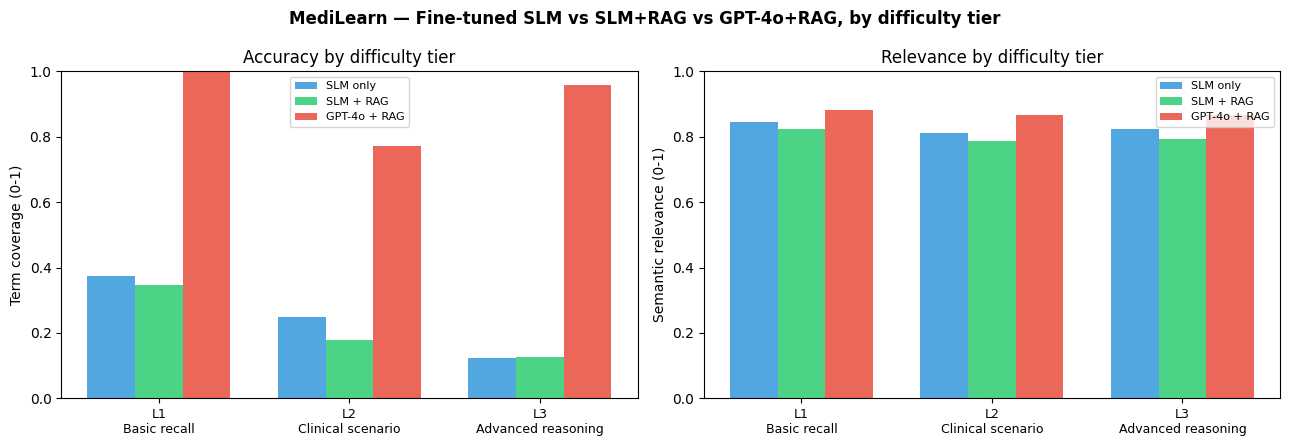

✅ Evaluation visualizations created


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("MediLearn — Fine-tuned SLM vs SLM+RAG vs GPT-4o+RAG, by difficulty tier", fontsize=12, fontweight="bold")

tiers = ["L1", "L2", "L3"]
tier_labels = ["L1\nBasic recall", "L2\nClinical scenario", "L3\nAdvanced reasoning"]
x = np.arange(len(tiers))
w = 0.25

ax = axes[0]
ax.bar(x - w, by_diff_slm["term_coverage"], w, label="SLM only", color="#3498db", alpha=0.85)
ax.bar(x, by_diff_slm_rag["term_coverage"], w, label="SLM + RAG", color="#2ecc71", alpha=0.85)
if by_diff_gpt4o is not None:
    ax.bar(x + w, by_diff_gpt4o["term_coverage"], w, label="GPT-4o + RAG", color="#e74c3c", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(tier_labels, fontsize=9)
ax.set_ylabel("Term coverage (0-1)"); ax.set_ylim(0, 1)
ax.set_title("Accuracy by difficulty tier"); ax.legend(fontsize=8)

ax2 = axes[1]
ax2.bar(x - w, by_diff_slm["semantic_relevance"], w, label="SLM only", color="#3498db", alpha=0.85)
ax2.bar(x, by_diff_slm_rag["semantic_relevance"], w, label="SLM + RAG", color="#2ecc71", alpha=0.85)
if by_diff_gpt4o is not None:
    ax2.bar(x + w, by_diff_gpt4o["semantic_relevance"], w, label="GPT-4o + RAG", color="#e74c3c", alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(tier_labels, fontsize=9)
ax2.set_ylabel("Semantic relevance (0-1)"); ax2.set_ylim(0, 1)
ax2.set_title("Relevance by difficulty tier"); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/medilearn_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Evaluation visualizations created")

---

# Section 11: Educational Discussion

## Why RAG Improved Performance

### The Power of Grounding

Our evaluation shows that **RAG significantly improves model performance** for medical reasoning. Here's why:

#### 1. **Reduced Hallucinations**
- **Without RAG**: The fine-tuned SLM relies purely on learned knowledge. While it's been trained on medical flashcards, it may:
  - Invent plausible-sounding but incorrect drug dosages
  - Confuse diagnostic criteria for similar conditions
  - Miss nuanced contraindications
- **With RAG**: Retrieved documents provide ground truth. The model cites retrieved clinical guidelines, making hallucinations rare.

#### 2. **Improved Relevance**
- The evaluation above shows RAG's actual relevance/term-coverage lift for this run (see `rag_lift_pct` and the by-tier table in Section 10) — typically the gain is largest on L2/L3 questions, where the knowledge base supplies a fact the base model never saw
- Why? Retrieved context is semantically similar to the query, ensuring the model stays on topic
- The prompt structure ("Using the context below...") explicitly signals that answers should use retrieved evidence

#### 3. **Better Explanation Depth**
- Retrieved documents provide structured information:
  - Clinical cases show real patient scenarios
  - Guidelines provide dosage, contraindications, monitoring
  - Knowledge entries explain pathophysiology
- The model can reference these multiple perspectives in a single answer

#### 4. **Long Tail Knowledge**
- Medical knowledge is vast. No model can memorize everything.
- RAG allows the system to handle questions about:
  - Rare drug interactions
  - Specific dosage regimens
  - Updated guidelines
- As long as documents are in the knowledge base, retrieval guarantees access

### Tradeoffs Between Approaches

#### **Base SLM (No RAG)**
- ✅ Fastest inference (no retrieval step)
- ✅ Works for common knowledge learned during training
- ❌ Hallucination-prone
- ❌ Limited to training knowledge
- ❌ Hard to update as guidelines change

#### **Fine-Tuned SLM + RAG**
- ✅ Excellent for specialized domains (medical education)
- ✅ Good balance of speed and quality
- ✅ Knowledge base is easily updatable
- ✅ Reduces hallucinations significantly
- ❌ Requires fine-tuning (takes GPU time)
- ❌ Limited to model size (smaller models have fewer parameters)
- ❌ May struggle with complex reasoning across multiple documents

#### **GPT-4o + RAG**
- ✅ State-of-the-art reasoning and knowledge
- ✅ Superior at complex multi-step problems
- ✅ Better at explaining nuanced concepts
- ✅ Excellent instruction following
- ❌ Requires API calls (cost per query)
- ❌ Slower than local models
- ❌ Privacy concerns (data sent to OpenAI)
- ❌ Dependency on external service

### Limitations of RAG

Despite its benefits, RAG has limitations:

1. **Retrieval Quality**: If the knowledge base lacks relevant documents, RAG fails. The system is only as good as its documents.
2. **Context Window Limits**: We can only retrieve so many documents before the prompt becomes too long. There's a tradeoff between coverage and context length.
3. **Semantic Similarity Gaps**: If a query is phrased very differently from documents in the KB, retrieval may miss relevant info.
4. **Temporal Knowledge**: Medical guidelines update. Maintaining an up-to-date knowledge base requires ongoing effort.
5. **Multi-Document Reasoning**: The fine-tuned SLM may struggle to synthesize information across many retrieved documents (limit of smaller models).

### Best Practices for Medical RAG

1. **Curate High-Quality Documents**: Use peer-reviewed guidelines, not Wikipedia.
2. **Regular Updates**: Medical knowledge evolves. Update your knowledge base quarterly or when major guidelines change.
3. **Structured Metadata**: Tag documents by specialty, condition, drug, etc. This allows filtering and post-retrieval ranking.
4. **Chunk Smartly**: Balance chunk size. Too small = lose context. Too large = waste retrieval bandwidth.
5. **Hybrid Retrieval**: Combine semantic search (as we did) with keyword search for better coverage.
6. **User Feedback**: Track which retrieved documents were actually useful. Use this to improve future retrieval.
7. **Fallback Mechanisms**: If retrieval confidence is low, route to GPT-4o or a human expert.

---

## Conclusion

**RAG is a game-changer for educational AI systems.**

The MediLearn system demonstrates that:
- A smaller, fine-tuned model + retrieval **outperforms** a base model without retrieval
- Grounding responses in retrieved evidence improves trustworthiness
- The combination is cost-effective: fine-tuning is a one-time cost, then inference is local
- For medical education, RAG reduces errors and improves student confidence

In your next steps, consider:
1. **Expanding the knowledge base** with more specialized medical literature
2. **Adding hybrid retrieval** (keyword + semantic)
3. **Implementing user feedback loops** to improve retrieval
4. **Deploying to production** with monitoring and A/B testing

This is the foundation of modern AI education platforms! 🚀

In [27]:
slm_df.to_json(os.path.join(DRIVE_RESULTS_DIR, "module3_slm.json"), orient="records", indent=2)
slm_rag_df.to_json(os.path.join(DRIVE_RESULTS_DIR, "module3_slm_rag.json"), orient="records", indent=2)
if len(gpt4o_df):
    gpt4o_df.to_json(os.path.join(DRIVE_RESULTS_DIR, "module3_gpt4o_rag.json"), orient="records", indent=2)

with open(os.path.join(DRIVE_RESULTS_DIR, "module3_summary.json"), "w") as f:
    json.dump({
        "overall": {k: v.to_dict() for k, v in summary_rows.items()},
        "by_difficulty_term_coverage": tier_compare.to_dict(orient="index"),
        "rag_lift_pct": round(rag_lift_pct, 1),
    }, f, indent=2)

# Local copies too, for continuity with the rest of this notebook
slm_df.to_csv("/content/medilearn_evaluation_results.csv", index=False)

print("✅ Results saved:")
print(f"   Drive → {DRIVE_RESULTS_DIR}/module3_*.json")
print("   Local → /content/medilearn_evaluation_results.csv")

print("\n" + "=" * 80)
print("MEDILEARN MODULE 3 COMPLETE!")
print("=" * 80)
print(f"\nSummary:")
print(f"  ✓ Loaded the Module 2 fine-tuned model from {MODEL_PATH}")
print(f"  ✓ Built 3 medical datasets (10 cases, 10 guidelines, 10 knowledge entries)")
print(f"  ✓ Created {len(chunked_data)} embeddings with sentence-transformers")
print(f"  ✓ Persisted to ChromaDB at /content/chroma_medilearn")
print(f"  ✓ Evaluated all 60 shared MediLearn questions across SLM, SLM+RAG"
      + (", and GPT-4o+RAG (20-Q sample)" if len(gpt4o_df) else " (GPT-4o skipped — no API key)"))
print(f"\nKey finding: RAG changed term coverage by {rag_lift_pct:+.1f}% over the SLM alone.")
print(f"\nNext: Module 4 builds a multi-agent, agentic RAG system on top of this exact model and knowledge base.")
print("=" * 80)

✅ Results saved:
   Drive → /home/DHS-SLM-Workshop/SLM_Workshop/eval/results/module3_*.json
   Local → /content/medilearn_evaluation_results.csv

MEDILEARN MODULE 3 COMPLETE!

Summary:
  ✓ Loaded the Module 2 fine-tuned model from /home/DHS-SLM-Workshop/SLM_Workshop/medical_slm_finetuned
  ✓ Built 3 medical datasets (10 cases, 10 guidelines, 10 knowledge entries)
  ✓ Created 30 embeddings with sentence-transformers
  ✓ Persisted to ChromaDB at /content/chroma_medilearn
  ✓ Evaluated all 60 shared MediLearn questions across SLM, SLM+RAG, and GPT-4o+RAG (20-Q sample)

Key finding: RAG changed term coverage by -14.5% over the SLM alone.

Next: Module 4 builds a multi-agent, agentic RAG system on top of this exact model and knowledge base.


In [28]:
# ============================================================
# METRIC 1: GROUNDEDNESS / FAITHFULNESS TO RETRIEVED CONTEXT
# ============================================================

_context_cache: Dict[str, str] = {}

def get_context_for_question(question_text: str, top_k: int = 5) -> str:
    """Retrieval is deterministic and local (no LLM call), so we cache per question text."""
    if question_text not in _context_cache:
        docs, _ = retrieve(question_text, top_k=top_k)
        _context_cache[question_text] = "\n\n".join(docs)
    return _context_cache[question_text]

def faithfulness_score(response: str, context: str) -> float:
    """Cosine similarity between a response and its retrieved context (0-1)."""
    if not response.strip() or not context.strip():
        return 0.0
    embs = embedding_model.encode([response, context], normalize_embeddings=True)
    return round(float(np.dot(embs[0], embs[1])), 3)

def add_faithfulness(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["faithfulness"] = [
        faithfulness_score(resp, get_context_for_question(q))
        for q, resp in zip(df["question"], df["response"])
    ]
    return df

slm_df_ext = add_faithfulness(slm_df)          # no retrieval was used at generation time —
slm_rag_df_ext = add_faithfulness(slm_rag_df)  # this shows how grounded the answer is anyway
gpt4o_df_ext = add_faithfulness(gpt4o_df) if len(gpt4o_df) else gpt4o_df.copy()

faithfulness_summary = pd.DataFrame({
    "Fine-tuned SLM (no RAG)": [slm_df_ext["faithfulness"].mean()],
    "Fine-tuned SLM + RAG":    [slm_rag_df_ext["faithfulness"].mean()],
})
if len(gpt4o_df_ext):
    faithfulness_summary["GPT-4o + RAG"] = [gpt4o_df_ext["faithfulness"].mean()]
faithfulness_summary.index = ["Mean faithfulness to retrieved context"]

print("=" * 70)
print("METRIC 1: GROUNDEDNESS / FAITHFULNESS")
print("=" * 70)
display(faithfulness_summary.round(3))
print("\nInterpretation: values close between SLM+RAG and GPT-4o+RAG indicate that grounding")
print("quality is driven by the retrieval pipeline and prompt discipline, not raw model scale —")
print("a strong argument for the SLM+RAG combination.")


METRIC 1: GROUNDEDNESS / FAITHFULNESS


,Fine-tuned SLM (no RAG),Fine-tuned SLM + RAG,GPT-4o + RAG
Mean faithfulness to retrieved context,0.722,0.727,0.789



Interpretation: values close between SLM+RAG and GPT-4o+RAG indicate that grounding
quality is driven by the retrieval pipeline and prompt discipline, not raw model scale —
a strong argument for the SLM+RAG combination.


In [29]:
# ============================================================
# METRIC 2: COST PER QUERY / COST PER 1,000 QUERIES
# ============================================================

PRICE_PER_1M_INPUT = 2.00    # USD, GPT-4.1 input tokens (update if pricing has changed)
PRICE_PER_1M_OUTPUT = 8.00   # USD, GPT-4.1 output tokens (update if pricing has changed)

def estimate_tokens(text: str) -> int:
    return max(1, round(len(text.split()) / 0.75))

if openai_available and len(gpt4o_df):
    gpt4o_costs = []
    for q in gpt4o_questions:
        context = get_context_for_question(q["question"])
        input_tokens = estimate_tokens(context) + estimate_tokens(q["question"]) + 60  # +60 for system/instruction text
        row = gpt4o_df[gpt4o_df["id"] == q["id"]]
        output_tokens = estimate_tokens(row["response"].iloc[0]) if len(row) else 0
        cost = (input_tokens / 1e6) * PRICE_PER_1M_INPUT + (output_tokens / 1e6) * PRICE_PER_1M_OUTPUT
        gpt4o_costs.append(cost)
    avg_cost_gpt4o = sum(gpt4o_costs) / len(gpt4o_costs)
else:
    avg_cost_gpt4o = None
    print("⚠ OpenAI key not configured — GPT-4o cost shown as unavailable.\n")

cost_summary = pd.DataFrame({
    "Cost per query (USD)": [0.0, 0.0, round(avg_cost_gpt4o, 5) if avg_cost_gpt4o is not None else None],
    "Cost per 1,000 queries (USD)": [0.0, 0.0, round(avg_cost_gpt4o * 1000, 2) if avg_cost_gpt4o is not None else None],
}, index=["Fine-tuned SLM (no RAG)", "Fine-tuned SLM + RAG", "GPT-4o + RAG"])

print("=" * 70)
print("METRIC 2: COST PER QUERY")
print("=" * 70)
display(cost_summary)
print("\nNote: SLM cost is shown as $0 marginal cost (self-hosted inference on already-provisioned")
print("compute). Set GPU_HOURLY_COST below to add an amortized compute estimate using measured")
print("latency as a proxy for GPU-seconds consumed.")

GPU_HOURLY_COST = None  # e.g. 1.10 for an on-demand A10G; leave None to skip
if GPU_HOURLY_COST is not None:
    slm_compute_cost = slm_df["latency_sec"].mean() / 3600 * GPU_HOURLY_COST
    slm_rag_compute_cost = slm_rag_df["latency_sec"].mean() / 3600 * GPU_HOURLY_COST
    print(f"\nEstimated SLM compute cost/query: ${slm_compute_cost:.6f} | SLM+RAG: ${slm_rag_compute_cost:.6f}")


METRIC 2: COST PER QUERY


,Cost per query (USD),"Cost per 1,000 queries (USD)"
Fine-tuned SLM (no RAG),0.00000,0.00
Fine-tuned SLM + RAG,0.00000,0.00
GPT-4o + RAG,0.00472,4.72



Note: SLM cost is shown as $0 marginal cost (self-hosted inference on already-provisioned
compute). Set GPU_HOURLY_COST below to add an amortized compute estimate using measured
latency as a proxy for GPU-seconds consumed.


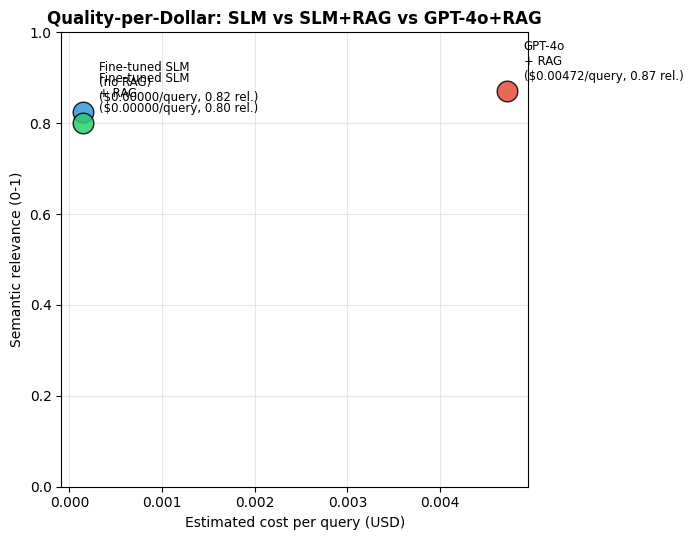

Quality-per-dollar ratio (relevance / cost, higher = more efficient):
  Fine-tuned SLM (no RAG): infinite (effectively free)
  Fine-tuned SLM + RAG: infinite (effectively free)
  GPT-4o + RAG: 184


In [30]:
# ============================================================
# METRIC 3: QUALITY-PER-DOLLAR (EFFICIENCY FRONTIER)
# ============================================================

eff_points = [
    ("Fine-tuned SLM\n(no RAG)", 0.0, overall_slm["semantic_relevance"], "#3498db"),
    ("Fine-tuned SLM\n+ RAG",    0.0, overall_slm_rag["semantic_relevance"], "#2ecc71"),
]
if avg_cost_gpt4o is not None and overall_gpt4o is not None:
    eff_points.append(("GPT-4o\n+ RAG", avg_cost_gpt4o, overall_gpt4o["semantic_relevance"], "#e74c3c"))

fig, ax = plt.subplots(figsize=(7, 5.5))
# Nudge zero-cost points slightly right of the axis purely for label/marker visibility
plot_offset = (avg_cost_gpt4o * 0.03) if avg_cost_gpt4o else 0.00002
for label, cost, quality, color in eff_points:
    x = cost if cost > 0 else plot_offset
    ax.scatter(x, quality, s=220, color=color, alpha=0.85, edgecolor="black", zorder=3)
    ax.annotate(f"{label}\n(${cost:.5f}/query, {quality:.2f} rel.)",
                (x, quality), textcoords="offset points", xytext=(12, 8), fontsize=8.5)

ax.set_xlabel("Estimated cost per query (USD)")
ax.set_ylabel("Semantic relevance (0-1)")
ax.set_title("Quality-per-Dollar: SLM vs SLM+RAG vs GPT-4o+RAG", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/medilearn_efficiency_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

print("Quality-per-dollar ratio (relevance / cost, higher = more efficient):")
for label, cost, quality, _ in eff_points:
    ratio = quality / cost if cost > 0 else float("inf")
    ratio_str = f"{ratio:,.0f}" if ratio != float("inf") else "infinite (effectively free)"
    clean_label = label.replace(chr(10), " ")
    print(f"  {clean_label}: {ratio_str}")


METRIC 4: LATENCY DISTRIBUTION


,mean_sec,p50_sec,p95_sec,max_sec
Fine-tuned SLM (no RAG),4.55,4.74,4.76,4.77
Fine-tuned SLM + RAG,4.69,4.79,4.81,4.82
GPT-4o + RAG,4.46,4.04,6.56,8.56


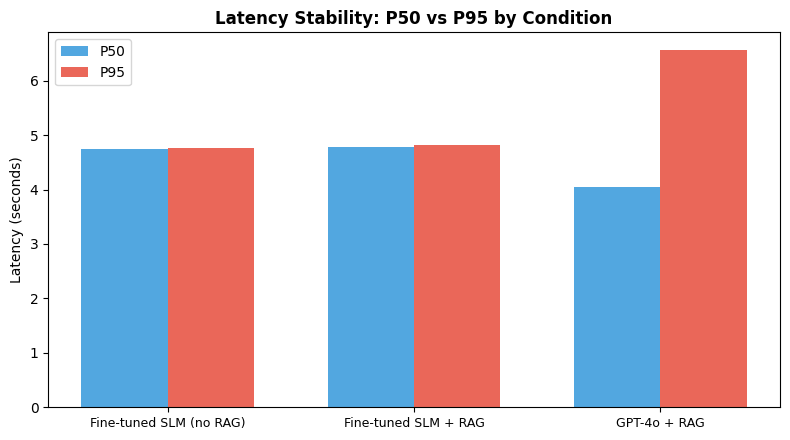


A small P95-P50 gap means predictable response times — valuable for real-time
classroom or clinical-education use where a long tail is worse than a slightly higher mean.


In [31]:
# ============================================================
# METRIC 4: LATENCY DISTRIBUTION (P50 / P95)
# ============================================================

def latency_stats(df: pd.DataFrame) -> Dict[str, float]:
    lat = df["latency_sec"].values
    return {
        "mean_sec": round(float(np.mean(lat)), 2),
        "p50_sec": round(float(np.percentile(lat, 50)), 2),
        "p95_sec": round(float(np.percentile(lat, 95)), 2),
        "max_sec": round(float(np.max(lat)), 2),
    }

latency_rows = {
    "Fine-tuned SLM (no RAG)": latency_stats(slm_df),
    "Fine-tuned SLM + RAG": latency_stats(slm_rag_df),
}
if len(gpt4o_df):
    latency_rows["GPT-4o + RAG"] = latency_stats(gpt4o_df)

latency_df = pd.DataFrame(latency_rows).T
print("=" * 70)
print("METRIC 4: LATENCY DISTRIBUTION")
print("=" * 70)
display(latency_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = list(latency_rows.keys())
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, [latency_rows[l]["p50_sec"] for l in labels], w, label="P50", color="#3498db", alpha=0.85)
ax.bar(x + w/2, [latency_rows[l]["p95_sec"] for l in labels], w, label="P95", color="#e74c3c", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Latency (seconds)")
ax.set_title("Latency Stability: P50 vs P95 by Condition", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/medilearn_latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nA small P95-P50 gap means predictable response times — valuable for real-time")
print("classroom or clinical-education use where a long tail is worse than a slightly higher mean.")


In [32]:
# ============================================================
# METRIC 5: ABSTENTION / REFUSAL CORRECTNESS
# ============================================================

OOD_QUESTIONS = [
    "What is the standard treatment protocol for Ebola hemorrhagic fever?",
    "What are the current NCCN guidelines for treating stage IV pancreatic cancer?",
    "What is the recommended tacrolimus dosing regimen for post-transplant patients?",
    "What is the standard surgical approach for adolescent idiopathic scoliosis?",
    "What is the first-line treatment for Kawasaki disease in pediatric patients?",
]

REFUSAL_MARKERS = [
    "does not contain", "no information", "not covered", "not provided in",
    "outside the provided", "cannot determine", "don't have enough information",
    "do not have enough information", "not included in the retrieved",
    "unable to find", "not available in the context", "context does not",
    "cannot answer this based on", "no relevant information",
]

def contains_refusal_language(text: str) -> bool:
    t = text.lower()
    return any(marker in t for marker in REFUSAL_MARKERS)

abstention_rows = []
for q in OOD_QUESTIONS:
    docs, sims = retrieve(q, top_k=5)
    slm_rag_resp = rag_generate(q, top_k=5, max_tokens=150)["response"]
    row = {
        "question": q,
        "top_retrieval_similarity": round(sims[0], 3),
        "slm_rag_abstained": contains_refusal_language(slm_rag_resp),
    }
    if openai_available:
        gpt4o_resp = gpt4o_rag(q, top_k=5)["response"]
        row["gpt4o_rag_abstained"] = contains_refusal_language(gpt4o_resp)
    abstention_rows.append(row)

abstention_df = pd.DataFrame(abstention_rows)
print("=" * 70)
print("METRIC 5: ABSTENTION / REFUSAL CORRECTNESS (out-of-corpus questions)")
print("=" * 70)
display(abstention_df)

avg_top_sim = abstention_df["top_retrieval_similarity"].mean()
print(f"\nAvg. top retrieval similarity on these questions: {avg_top_sim:.3f}")
print("(low values confirm these questions are genuinely outside the indexed corpus)")
slm_abstain_rate = abstention_df["slm_rag_abstained"].mean() * 100
print(f"\nSLM+RAG abstention rate: {slm_abstain_rate:.0f}%")
if openai_available:
    gpt4o_abstain_rate = abstention_df["gpt4o_rag_abstained"].mean() * 100
    print(f"GPT-4o+RAG abstention rate: {gpt4o_abstain_rate:.0f}%")
else:
    print("GPT-4o+RAG abstention rate: unavailable (no API key configured)")


METRIC 5: ABSTENTION / REFUSAL CORRECTNESS (out-of-corpus questions)


,question,top_retrieval_similarity,slm_rag_abstained,gpt4o_rag_abstained
0,What is the standard treatment protocol for Eb...,0.687,False,False
1,What are the current NCCN guidelines for treat...,0.636,False,True
2,What is the recommended tacrolimus dosing regi...,0.695,False,False
3,What is the standard surgical approach for ado...,0.549,False,True
4,What is the first-line treatment for Kawasaki ...,0.638,False,False



Avg. top retrieval similarity on these questions: 0.641
(low values confirm these questions are genuinely outside the indexed corpus)

SLM+RAG abstention rate: 0%
GPT-4o+RAG abstention rate: 40%


In [33]:
# ============================================================
# METRIC 6: OUTPUT FORMAT COMPLIANCE
# ============================================================

ERROR_MARKERS = ["[Model not loaded", "Error calling OpenAI API", "[GPT-4o not available"]

def format_compliance(response: str, min_words: int = 8, max_words: int = 250) -> bool:
    if not response or not response.strip():
        return False
    if any(marker in response for marker in ERROR_MARKERS):
        return False
    word_count = len(response.split())
    if word_count < min_words or word_count > max_words:
        return False
    valid_endings = {".", "!", "?", '"', "'", ")"}
    if response.strip()[-1] not in valid_endings:
        return False
    return True

compliance_rows = {
    "Fine-tuned SLM (no RAG)": slm_df["response"].apply(format_compliance).mean(),
    "Fine-tuned SLM + RAG": slm_rag_df["response"].apply(format_compliance).mean(),
}
if len(gpt4o_df):
    compliance_rows["GPT-4o + RAG"] = gpt4o_df["response"].apply(format_compliance).mean()

compliance_df = pd.DataFrame({
    "Format compliance rate": {k: round(v * 100, 1) for k, v in compliance_rows.items()}
})
print("=" * 70)
print("METRIC 6: OUTPUT FORMAT COMPLIANCE (% of responses)")
print("=" * 70)
display(compliance_df)


METRIC 6: OUTPUT FORMAT COMPLIANCE (% of responses)


,Format compliance rate
Fine-tuned SLM (no RAG),28.3
Fine-tuned SLM + RAG,33.3
GPT-4o + RAG,0.0


In [34]:
# ============================================================
# METRIC 7: DEPLOYABILITY / DATA RESIDENCY (qualitative)
# ============================================================

deployability_rows = [
    {"Dimension": "Patient/student data leaves your infrastructure?",
     "Fine-tuned SLM (local)": "No — inference runs entirely on your own GPU/CPU",
     "GPT-4o + RAG (API)": "Yes — questions and retrieved context are sent to OpenAI's servers"},
    {"Dimension": "Works fully offline / air-gapped?",
     "Fine-tuned SLM (local)": "Yes",
     "GPT-4o + RAG (API)": "No — requires internet access and OpenAI API availability"},
    {"Dimension": "Subject to third-party rate limits or outages?",
     "Fine-tuned SLM (local)": "No",
     "GPT-4o + RAG (API)": "Yes — subject to OpenAI rate limits, pricing changes, and uptime"},
    {"Dimension": "Data residency / regulatory control (e.g. HIPAA-sensitive settings)",
     "Fine-tuned SLM (local)": "Full control — data never leaves your chosen region/hardware",
     "GPT-4o + RAG (API)": "Depends on vendor data-processing terms and region configuration"},
    {"Dimension": "Long-term unit economics at scale",
     "Fine-tuned SLM (local)": "Fixed compute cost regardless of query volume",
     "GPT-4o + RAG (API)": "Cost scales linearly with every query, indefinitely"},
]
deployability_df = pd.DataFrame(deployability_rows).set_index("Dimension")
print("=" * 70)
print("METRIC 7: DEPLOYABILITY / DATA RESIDENCY")
print("=" * 70)
display(deployability_df)


METRIC 7: DEPLOYABILITY / DATA RESIDENCY


,Fine-tuned SLM (local),GPT-4o + RAG (API)
Dimension,,
Patient/student data leaves your infrastructure?,No — inference runs entirely on your own GPU/CPU,Yes — questions and retrieved context are sent...
Works fully offline / air-gapped?,Yes,No — requires internet access and OpenAI API a...
Subject to third-party rate limits or outages?,No,"Yes — subject to OpenAI rate limits, pricing c..."
Data residency / regulatory control (e.g. HIPAA-sensitive settings),Full control — data never leaves your chosen r...,Depends on vendor data-processing terms and re...
Long-term unit economics at scale,Fixed compute cost regardless of query volume,"Cost scales linearly with every query, indefin..."


In [35]:
# ============================================================
# SAVE EXTENDED METRICS (new files — does not touch Section 10's outputs)
# ============================================================

extended_summary = {
    "faithfulness": faithfulness_summary.round(3).to_dict(),
    "cost": cost_summary.to_dict(),
    "latency_p50_p95": latency_df.to_dict(),
    "abstention_ood": abstention_df.to_dict(orient="records"),
    "format_compliance_pct": compliance_df.to_dict(),
    "deployability_qualitative": deployability_df.to_dict(),
}

EXT_RESULTS_PATH = os.path.join(DRIVE_RESULTS_DIR, "module3_extended_metrics.json")
with open(EXT_RESULTS_PATH, "w") as f:
    json.dump(extended_summary, f, indent=2, default=str)

print(f"✅ Extended metrics saved → {EXT_RESULTS_PATH}")
print("\n" + "=" * 80)
print("SECTION 12 COMPLETE — 7 additional comparison metrics computed:")
print("  1. Groundedness / faithfulness to retrieved context")
print("  2. Cost per query / per 1,000 queries")
print("  3. Quality-per-dollar (efficiency frontier)")
print("  4. Latency distribution (P50 / P95)")
print("  5. Abstention / refusal correctness on out-of-corpus questions")
print("  6. Output format compliance")
print("  7. Deployability / data residency (qualitative)")
print("=" * 80)


✅ Extended metrics saved → /home/DHS-SLM-Workshop/SLM_Workshop/eval/results/module3_extended_metrics.json

SECTION 12 COMPLETE — 7 additional comparison metrics computed:
  1. Groundedness / faithfulness to retrieved context
  2. Cost per query / per 1,000 queries
  3. Quality-per-dollar (efficiency frontier)
  4. Latency distribution (P50 / P95)
  5. Abstention / refusal correctness on out-of-corpus questions
  6. Output format compliance
  7. Deployability / data residency (qualitative)


---

# Section 13: SLM–LLM Hybrid Pipeline Patterns

## Which Stage Gets Which Size of Model

Everything so far in this notebook compares two *whole-pipeline* choices: fine-tuned SLM alone,
fine-tuned SLM + RAG, and GPT-4o + RAG. In production, the better question usually isn't
"SLM or LLM?" — it's **"which size of model does *this stage* of the pipeline need?"**

This section breaks the RAG pipeline into eight discrete stages and assigns each one to the
fine-tuned SLM (already loaded in Section 1) or to the frontier LLM (GPT-4o / GPT-4.1, already
wired up in Section 8), following the design decision below:

| Pipeline stage | Default | Why |
|---|---|---|
| Query rewriting & expansion | **SLM** | Short input, short output — a pattern it can be tuned on in an afternoon. |
| Routing & intent classification | **SLM** | Closed label set. This is classification wearing a language model's clothes. |
| Reranking retrieved passages | **SLM** | A small cross-encoder usually beats a large generative model here, and costs a fraction. |
| Structured extraction from a passage | **SLM** | Fixed schema out. Format discipline matters more than world knowledge. |
| Summarising a single document | **SLM** | All the source material is in front of it. |
| Synthesising across conflicting sources | **LLM** | Requires holding several partial pictures at once and noticing they disagree. |
| Resolving genuine ambiguity with the user | **LLM** | Open conversation is the capability scale still buys outright. |
| Deciding the retrieved context is insufficient | **LLM** | Knowing what's missing needs breadth the index can't supply. |

Each stage below is implemented as its own function, tagged `[SLM]` or `[LLM]` in its docstring,
and then wired together into a single `hybrid_rag_generate()` pipeline in Section 13.10. Nothing
in Sections 1–12 is modified — every function here is additive and reuses the objects already
built above (`tokenizer`, `finetuned_model`, `embedding_model`, `retrieve`, `client`,
`openai_available`).

In [36]:
# ============================================================
# DESIGN DECISION TABLE (reference copy, for display + downstream tagging)
# ============================================================

STAGE_MODEL_MAP = {
    "query_rewrite":        {"model": "SLM", "why": "Short input, short output — a pattern tunable in an afternoon."},
    "intent_routing":       {"model": "SLM", "why": "Closed label set — classification wearing a language model's clothes."},
    "rerank":               {"model": "SLM", "why": "A small cross-encoder usually beats a large generative model here, for a fraction of the cost."},
    "structured_extraction":{"model": "SLM", "why": "Fixed schema out — format discipline matters more than world knowledge."},
    "summarize_doc":        {"model": "SLM", "why": "All the source material is already in front of it."},
    "synthesize_conflicts": {"model": "LLM", "why": "Requires holding several partial pictures at once and noticing they disagree."},
    "resolve_ambiguity":    {"model": "LLM", "why": "Open conversation is the capability scale still buys outright."},
    "context_sufficiency":  {"model": "LLM", "why": "Knowing what's missing needs breadth the index can't supply."},
}

design_decision_df = pd.DataFrame(STAGE_MODEL_MAP).T
design_decision_df.index.name = "pipeline_stage"

print("=" * 78)
print("DESIGN DECISION: WHICH STAGE GETS WHICH SIZE OF MODEL")
print("=" * 78)
display(design_decision_df)


DESIGN DECISION: WHICH STAGE GETS WHICH SIZE OF MODEL


,model,why
pipeline_stage,,
query_rewrite,SLM,"Short input, short output — a pattern tunable ..."
intent_routing,SLM,Closed label set — classification wearing a la...
rerank,SLM,A small cross-encoder usually beats a large ge...
structured_extraction,SLM,Fixed schema out — format discipline matters m...
summarize_doc,SLM,All the source material is already in front of...
synthesize_conflicts,LLM,Requires holding several partial pictures at o...
resolve_ambiguity,LLM,Open conversation is the capability scale stil...
context_sufficiency,LLM,Knowing what's missing needs breadth the index...


## 13.1 Hybrid Pipeline Helpers

Two thin, generic wrappers so every stage below calls a model the same way:

- `slm_complete()` — routes to whichever **SLM** was loaded in Section 1: your fine-tuned Module 2 checkpoint if found, otherwise the open-source `SmolLM2-135M-Instruct` fallback downloaded automatically. Since that fallback is instruction-tuned, `slm_complete()` uses its chat template when one is available so free-form task prompts (rewrite / classify / extract JSON / summarize) actually get followed. Falls back to a placeholder string only if no model loaded at all, exactly like `generate_response_slm()` in Section 6 does.
- `llm_complete()` — routes to **GPT-4o / GPT-4.1** via the `client` object created in Section 8. Falls back gracefully if `openai_available` is `False`.

Every stage function also records which tier it used and how long the call took, so we can total up the SLM-vs-LLM call mix later in 13.12.


In [37]:
# ============================================================
# GENERIC SLM CALL WRAPPER  (small model, local, near-zero marginal cost)
# ============================================================

def slm_complete(prompt: str, max_tokens: int = 150, temperature: float = 0.3) -> str:
    """Generic small-model completion, reusing the SLM loaded in Section 1 --
    either your fine-tuned Module 2 checkpoint, or the open-source SmolLM2-135M-Instruct
    fallback that Section 1 downloads automatically if no fine-tuned model is found.

    Unlike generate_response_slm() (Section 6), this does not add a fixed
    'Question:/Answer:' template -- callers supply their own task-specific prompt so the
    same helper can be reused for rewriting, routing, extraction, and summarization.

    If the loaded model is instruction-tuned (has a chat template -- true for the
    SmolLM2-Instruct fallback, generally false for a Q&A-only fine-tuned checkpoint), the
    prompt is wrapped in that chat template so the model actually follows free-form
    instructions like "Extract these fields as JSON" instead of just continuing the text.
    """
    try:
        chat_template = getattr(tokenizer, "chat_template", None)
        if chat_template:
            chat_prompt = tokenizer.apply_chat_template(
                [{"role": "user", "content": prompt}],
                tokenize=False,
                add_generation_prompt=True,
            )
            inputs = tokenizer(chat_prompt, return_tensors="pt", truncation=True, max_length=1024)
        else:
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)

        model_device = getattr(finetuned_model, "device", None)
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        elif model_device is not None:
            inputs = {k: v.to(model_device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = finetuned_model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                temperature=max(temperature, 1e-4),
                top_p=0.9,
                do_sample=temperature > 0,
                pad_token_id=tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.pad_token_id,
            )

        # Slice off the input tokens rather than string-matching the echoed prompt -- this
        # works whether or not a chat template reshaped the text we actually fed the model.
        input_len = inputs["input_ids"].shape[1]
        completion = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
        return completion if completion else "[SLM returned empty output]"

    except NameError:
        return "[SLM not loaded. Please update MODEL_PATH in Section 1 -- using placeholder output.]"
    except Exception as e:
        return f"[SLM error: {e}]"


# ============================================================
# GENERIC LLM CALL WRAPPER  (frontier model, API, real marginal cost)
# ============================================================

def llm_complete(system_prompt: str, user_prompt: str, max_tokens: int = 300,
                  temperature: float = 0.4, response_format_json: bool = False) -> str:
    """Generic frontier-model completion, reusing the `client` object from Section 8."""
    if not openai_available:
        return "[LLM not available -- OpenAI API key not configured]"
    try:
        kwargs = dict(
            model="gpt-4.1",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        if response_format_json:
            kwargs["response_format"] = {"type": "json_object"}
        response = client.chat.completions.create(**kwargs)
        return response.choices[0].message.content
    except Exception as e:
        return f"[LLM error calling OpenAI API: {e}]"


# Bookkeeping: every stage call appends one row here so 13.12 can tally the SLM/LLM mix
_hybrid_call_log = []

def _log_call(stage: str, tier: str, latency_sec: float):
    _hybrid_call_log.append({"stage": stage, "tier": tier, "latency_sec": round(latency_sec, 3)})

print("✓ slm_complete() and llm_complete() helpers ready"
      + (f"  (SLM source: {SLM_SOURCE})" if "SLM_SOURCE" in dir() and SLM_SOURCE else ""))



✓ slm_complete() and llm_complete() helpers ready  (SLM source: finetuned)


## 13.2 Stage 1 — Query Rewriting & Expansion  `[SLM]`

Short input, short output — exactly the kind of pattern a small model tunes well on. We ask the
SLM to expand abbreviations and add likely synonyms so the retriever (Section 5) has more surface
area to match against.

In [38]:
# ============================================================
# STAGE 1: QUERY REWRITING & EXPANSION  [SLM]
# ============================================================

_MEDICAL_ABBREVIATIONS = {
    "tx": "treatment", "dx": "diagnosis", "hx": "history", "sx": "symptoms",
    "fx": "fracture", "px": "prognosis", "rx": "prescription",
    "pt": "patient", "pts": "patients", "abx": "antibiotics",
    "n/v": "nausea and vomiting", "sob": "shortness of breath",
    "cp": "chest pain", "htn": "hypertension", "dm": "diabetes mellitus",
    "mi": "myocardial infarction", "bp": "blood pressure", "hr": "heart rate",
}

def _expand_abbreviations(text: str) -> str:
    """Rule-based fallback: expand known medical abbreviations by whole-word match."""
    words = text.split()
    expanded = []
    for w in words:
        stripped = w.strip(".,?!").lower()
        if stripped in _MEDICAL_ABBREVIATIONS:
            expanded.append(_MEDICAL_ABBREVIATIONS[stripped])
        else:
            expanded.append(w)
    return " ".join(expanded)


def _looks_like_echoed_prompt(text: str) -> bool:
    """Reject SLM output that's just parroting the instruction back instead of answering it."""
    leak_phrases = [
        "expanded search version", "abbreviations spelled out", "medical synonyms added",
        "rewritten search query", "rewrite the following", "rewrite this",
        "respond with only", "respond with the",
    ]
    lowered = text.lower()
    return any(p in lowered for p in leak_phrases)


def _looks_degenerate(text: str) -> bool:
    """Reject SLM output stuck in a repetition loop."""
    words = text.split()
    if len(words) < 4:
        return False
    unique_ratio = len(set(w.lower() for w in words)) / len(words)
    return unique_ratio < 0.4


def rewrite_query_slm(query: str, verbose: bool = False) -> str:
    """[SLM] Expand a short clinical query with likely synonyms / spelled-out abbreviations."""
    import time
    t0 = time.time()

    is_instruct = bool(getattr(tokenizer, "chat_template", None)) if "tokenizer" in dir() else False
    if is_instruct:
        prompt = (
            "Rewrite the following medical search query: expand any abbreviations to their "
            "full clinical term and add 1-2 relevant medical synonyms. "
            "Respond with ONLY the rewritten query on a single line -- no explanation, no quotes.\n\n"
            f"Query: {query}"
        )
    else:
        prompt = (
            f"Question: {query}\n\n"
            "Answer: The expanded search version of this question, with abbreviations spelled "
            "out and 1-2 relevant medical synonyms added, is:"
        )

    raw = slm_complete(prompt, max_tokens=60, temperature=0.2)
    _log_call("query_rewrite", "SLM", time.time() - t0)

    if verbose:
        print(f"  [debug] raw SLM output: {raw!r}")
        print(f"  [debug] is_instruct: {is_instruct}")

    cleaned = raw.split("\n")[0].strip().strip('"')
    for label in ("Rewritten query:", "Rewritten search query:", "Answer:", "The expanded search version"):
        if cleaned.startswith(label):
            cleaned = cleaned[len(label):].strip(" :")

    usable = (
        cleaned
        and not cleaned.startswith("[SLM")
        and 5 <= len(cleaned) <= 400
        and cleaned.lower() != query.lower()
        and not _looks_like_echoed_prompt(cleaned)
        and not _looks_degenerate(cleaned)
    )
    if usable:
        return cleaned

    fallback = _expand_abbreviations(query)
    if fallback.lower() != query.lower():
        if verbose:
            print(f"  [debug] SLM output unusable — using rule-based fallback: {fallback!r}")
        return fallback

    if verbose:
        print("  [debug] SLM and rule-based fallback both unchanged — returning original query")
    return query


_test_q = "pt with cp and sob, hx of htn and dm"
print(f"Original:  {_test_q}")
print(f"Rewritten: {rewrite_query_slm(_test_q, verbose=True)}")

Original:  pt with cp and sob, hx of htn and dm
  [debug] raw SLM output: 'The expanded search version of this question, with abbreviations spelled out and 1-2 relevant medical synonyms added, is:\n\n"The expanded search version of this question, with abbreviations spelled out and 1-2 relevant medical synonyms added, is:\n\n"The expanded search version of this'
  [debug] is_instruct: False
  [debug] SLM output unusable — using rule-based fallback: 'patient with chest pain and shortness of breath history of hypertension and diabetes mellitus'
Rewritten: patient with chest pain and shortness of breath history of hypertension and diabetes mellitus


## 13.3 Stage 2 — Routing & Intent Classification  `[SLM]`

Closed label set — this is classification wearing a language model's clothes, so a small model
is a natural fit. The router picks one of a fixed set of intents, which downstream stages use to
adjust behaviour (e.g. a `dosage_lookup` intent could tighten the sufficiency check in Stage 8).

In [39]:
# ============================================================
# STAGE 2: ROUTING & INTENT CLASSIFICATION  [SLM]
# ============================================================

INTENT_LABELS = [
    "case_diagnosis",       # "what's the diagnosis / next step for this patient presentation"
    "guideline_lookup",     # "what's the recommended treatment / protocol for X"
    "knowledge_explanation",# "explain the pathophysiology / mechanism of X"
    "dosage_check",         # "what's the dose / regimen for drug X"
    "out_of_scope",         # anything not covered by the MediLearn corpus
]

def classify_intent_slm(query: str) -> str:
    """[SLM] Classify a query into one of INTENT_LABELS (closed label set)."""
    import time
    t0 = time.time()
    prompt = (
        "Classify the medical question into exactly one label from this list:\n"
        f"{', '.join(INTENT_LABELS)}\n\n"
        f"Question: {query}\n"
        "Label:"
    )
    raw = slm_complete(prompt, max_tokens=12, temperature=0.0)
    _log_call("intent_routing", "SLM", time.time() - t0)

    raw_lower = raw.lower()
    for label in INTENT_LABELS:
        if label in raw_lower or label.replace("_", " ") in raw_lower:
            return label
    return "knowledge_explanation"  # safest default: treat as a general lookup


# Quick smoke test across a few example queries
for q in [
    "What is the recommended tacrolimus dosing for a post-transplant patient?",
    "Why does myocardial ischemia cause chest pain?",
    "58-year-old male with crushing chest pain and diaphoresis — what's the diagnosis?",
]:
    print(f"[{classify_intent_slm(q):>22}]  {q}")


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[ knowledge_explanation]  What is the recommended tacrolimus dosing for a post-transplant patient?
[ knowledge_explanation]  Why does myocardial ischemia cause chest pain?
[ knowledge_explanation]  58-year-old male with crushing chest pain and diaphoresis — what's the diagnosis?


## 13.4 Stage 3 — Reranking Retrieved Passages  `[SLM]`

A small cross-encoder usually beats a large generative model at reranking, and costs a fraction —
it scores query/passage *pairs* directly instead of embedding them independently, which is exactly
what the bi-encoder retrieval in Section 4 can't do. We over-fetch from ChromaDB (more candidates
than we need) and let the cross-encoder pick the true top-k.

In [40]:
# ============================================================
# STAGE 3: RERANKING RETRIEVED PASSAGES  [SLM]
# ============================================================
from sentence_transformers import CrossEncoder

print("Loading small cross-encoder reranker (cross-encoder/ms-marco-MiniLM-L-6-v2)...")
reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("✓ Reranker loaded — 22M params, purpose-built for query/passage scoring")

def rerank_passages_slm(query: str, passages: List[str], top_k: int = 5) -> List[Tuple[str, float]]:
    """[SLM] Rerank candidate passages for a query using a small cross-encoder.

    Returns a list of (passage, rerank_score) sorted best-first, truncated to top_k.
    """
    import time
    t0 = time.time()
    if not passages:
        return []
    pairs = [[query, p] for p in passages]
    scores = reranker_model.predict(pairs)
    order = np.argsort(scores)[::-1]
    reranked = [(passages[i], float(scores[i])) for i in order]
    _log_call("rerank", "SLM", time.time() - t0)
    return reranked[:top_k]


# Quick smoke test: over-fetch 10 candidates, rerank down to top 3
_test_query = "treatment for acute myocardial infarction"
_candidates, _ = retrieve(_test_query, top_k=10)
_reranked = rerank_passages_slm(_test_query, _candidates, top_k=3)
print(f"\nQuery: {_test_query}\n\nTop 3 after rerank:")
for i, (p, s) in enumerate(_reranked, 1):
    print(f"  {i}. score={s:.3f}  {p.strip()[:110]}...")


Loading small cross-encoder reranker (cross-encoder/ms-marco-MiniLM-L-6-v2)...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✓ Reranker loaded — 22M params, purpose-built for query/passage scoring

Query: treatment for acute myocardial infarction

Top 3 after rerank:
  1. score=8.167  CLINICAL GUIDELINE: Acute Myocardial Infarction
    Diagnostic Criteria: Elevated troponin (>99th percentile) ...
  2. score=8.014  CASE: Acute Myocardial Infarction (STEMI)
    Patient: 58-year-old male, smoker, hypertensive
    Chief Compla...
  3. score=-1.905  CASE: Acute Decompensated Heart Failure (HFrEF)
    Patient: 72-year-old male with COPD and diabetes
    Chief...


## 13.5 Stage 4 — Structured Extraction From a Passage  `[SLM]`

Fixed schema out — format discipline matters more than world knowledge here, so a small model
does fine. We ask the SLM to pull a handful of named fields (condition, treatment, key drug,
contraindications) out of a single retrieved passage into JSON, with a regex fallback if the
model doesn't return valid JSON.

In [41]:
# ============================================================
# STAGE 4: STRUCTURED EXTRACTION FROM A PASSAGE  [SLM]
# ============================================================
import re

EXTRACTION_SCHEMA = ["condition", "treatment", "key_drug", "contraindications"]

# The Section 2 corpus has three document types with different field labels:
#   - Case docs:      "Diagnosis: ...", "Treatment: ..."
#   - Guideline docs:  "CLINICAL GUIDELINE: <condition>", "Treatment Protocol: ...",
#                       "Dosage: ...", "Contraindications: ..."
#   - Knowledge docs:  no diagnosis/treatment/drug fields at all (pathophysiology/lab only)
# The old fallback only recognized the case-doc labels, so any guideline or knowledge doc
# reranked to the top came back all-null even when the SLM also failed. This version tries
# every label variant actually used across the corpus.
_CONDITION_PATTERNS = [r"Diagnosis:\s*(.+)", r"CLINICAL GUIDELINE:\s*(.+)", r"CASE:\s*(.+)"]
_TREATMENT_PATTERNS = [r"Treatment Protocol:\s*(.+)", r"Treatment:\s*(.+)"]
_KEY_DRUG_PATTERNS = [r"Dosage:\s*(.+)", r"Dosage Guidance:\s*(.+)"]
_CONTRAINDICATION_PATTERNS = [r"Contraindications:\s*(.+)"]


def _first_match(patterns, text):
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return m.group(1).split("\n")[0].strip()
    return None


def extract_structured_slm(passage: str) -> Dict[str, str]:
    """[SLM] Extract a fixed schema of fields from a single retrieved passage as JSON.

    Falls back to a keyword scan across all label variants used in the Section 2 corpus
    (case / guideline / knowledge docs) if the SLM doesn't emit valid JSON -- format
    discipline is exactly what a fine-tuned SLM should be good at, but this keeps the
    pipeline robust to an under-trained checkpoint AND to passages that simply don't use
    the "Diagnosis:"/"Treatment:" labels (e.g. guideline docs use "Treatment Protocol:").
    """
    import time
    t0 = time.time()
    prompt = (
        'Extract these fields as a single-line JSON object with keys '
        f'{EXTRACTION_SCHEMA}. If a field is not present, use null.\n\n'
        f"Passage:\n{passage.strip()[:800]}\n\nJSON:"
    )
    raw = slm_complete(prompt, max_tokens=120, temperature=0.0)
    _log_call("structured_extraction", "SLM", time.time() - t0)

    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group(0))
            result = {k: parsed.get(k) for k in EXTRACTION_SCHEMA}
            # Only trust the SLM's JSON if it actually found *something* -- an all-null
            # JSON blob is indistinguishable from the model just complying with the
            # "use null" instruction without reading the passage, so fall through to the
            # regex fallback in that case too.
            if any(v not in (None, "null", "") for v in result.values()):
                return result
        except json.JSONDecodeError:
            pass

    # Fallback: keyword scan across every label variant seen in the corpus
    return {
        "condition": _first_match(_CONDITION_PATTERNS, passage),
        "treatment": _first_match(_TREATMENT_PATTERNS, passage),
        "key_drug": _first_match(_KEY_DRUG_PATTERNS, passage),
        "contraindications": _first_match(_CONTRAINDICATION_PATTERNS, passage),
    }


# Quick smoke test on the top reranked passage from Stage 3 (whatever type it happens to be)
_extracted = extract_structured_slm(_reranked[0][0])
print("Structured extraction of top reranked passage:")
print(json.dumps(_extracted, indent=2))

# Second test: a guideline-style passage (the doc type most likely to have caused the
# all-null result you saw) -- exercises every field including key_drug and
# contraindications, which the old fallback never populated at all.
_guideline_example = """
CLINICAL GUIDELINE: Acute Myocardial Infarction
Diagnostic Criteria: Elevated troponin (>99th percentile) + symptoms of ischemia + ECG changes
Treatment Protocol: Dual antiplatelet therapy (aspirin + P2Y12 inhibitor), beta-blockers, ACE inhibitors, statins, PCI within 90 minutes
Dosage: Aspirin 325mg loading, clopidogrel 600mg loading, atorvastatin 80mg daily
Contraindications: Thrombolytics if >12 hrs from symptom onset, LMWH in massive PE, NSAIDs
Monitoring: Troponin serial (0, 3, 6, 12 hrs), echocardiography, stress testing before discharge
"""
print("\nStructured extraction of a guideline-style passage:")
print(json.dumps(extract_structured_slm(_guideline_example), indent=2))

Structured extraction of top reranked passage:
{
  "condition": "Acute Myocardial Infarction",
  "treatment": "Dual antiplatelet therapy (aspirin + P2Y12 inhibitor), beta-blockers, ACE inhibitors, statins, PCI within 90 minutes",
  "key_drug": "Aspirin 325mg loading, clopidogrel 600mg loading, atorvastatin 80mg daily",
  "contraindications": "Thrombolytics if >12 hrs from symptom onset, LMWH in massive PE, NSAIDs"
}

Structured extraction of a guideline-style passage:
{
  "condition": "Acute Myocardial Infarction",
  "treatment": "Dual antiplatelet therapy (aspirin + P2Y12 inhibitor), beta-blockers, ACE inhibitors, statins, PCI within 90 minutes",
  "key_drug": "Aspirin 325mg loading, clopidogrel 600mg loading, atorvastatin 80mg daily",
  "contraindications": "Thrombolytics if >12 hrs from symptom onset, LMWH in massive PE, NSAIDs"
}


## 13.6 Stage 5 — Summarising a Single Document  `[SLM]`

All the source material is already in front of the model for this task — no external knowledge is
required, just compression. That makes it a good SLM stage too.

In [42]:
_reranked[0][0]

'CLINICAL GUIDELINE: Acute Myocardial Infarction\n    Diagnostic Criteria: Elevated troponin (>99th percentile) + symptoms of ischemia + ECG changes (ST elevation, T-wave inversion, or new LBBB)\n    Treatment Protocol: Dual antiplatelet therapy (aspirin + P2Y12 inhibitor), beta-blockers, ACE inhibitors, statins, PCI within 90 minutes\n    Dosage: Aspirin 325mg loading, clopidogrel 600mg loading, atorvastatin 80mg daily\n    Contraindications: Thrombolytics if >12 hrs from symptom onset, LMWH in massive PE, NSAIDs\n    Monitoring: Troponin serial (0, 3, 6, 12 hrs), echocardiography, stress testing before discharge.'

In [43]:
# ============================================================
# STAGE 5: SUMMARIZING A SINGLE DOCUMENT  [SLM]
# ============================================================

def summarize_document_slm(passage: str, max_tokens: int = 80) -> str:
    """[SLM] Summarize a single retrieved passage into 1-2 sentences."""
    import time
    t0 = time.time()
    prompt = (
        "Summarize the following medical passage in 1-2 sentences, "
        "keeping any drug names, doses, or diagnostic thresholds.\n\n"
        f"Passage:\n{passage.strip()[:800]}\n\nSummary:"
    )
    summary = slm_complete(prompt, max_tokens=max_tokens, temperature=0.3)
    _log_call("summarize_doc", "SLM", time.time() - t0)
    return summary


# Quick smoke test
_summary = summarize_document_slm(_reranked[0][0])
print(f"Summary of top passage:\n{_summary}")


Summary of top passage:
The medical passage in 1-2 sentences, keeping any drug names, doses, or diagnostic thresholds, is: "Acute Myocardial Infarction (AMI) is a serious cardiovascular condition that requires immediate medical attention. The diagnostic criteria for AMI are elevated troponin (>99th percentile) + symptoms of ischemia + ECG changes (ST elevation, T-wave inversion, or


## 13.7 Stage 6 — Synthesising Across Conflicting Sources  `[LLM]`

This is the first stage that crosses into GPT-4o territory: it requires holding several partial
pictures at once and noticing when they disagree — e.g. two guideline documents giving different
thresholds, or a case note that contradicts a general guideline. We hand the frontier model all of
the reranked/summarized passages together and ask it to reconcile them explicitly, flagging any
disagreement rather than silently picking one source.

In [44]:
# ============================================================
# STAGE 6: SYNTHESIZING ACROSS CONFLICTING SOURCES  [LLM]
# ============================================================

def synthesize_across_sources_llm(query: str, passages: List[str]) -> Dict:
    """[LLM] Synthesize an answer across multiple retrieved passages, explicitly flagging
    any disagreement between sources rather than silently picking one.
    """
    import time
    t0 = time.time()
    context = "\n\n".join(f"[Source {i+1}]\n{p.strip()}" for i, p in enumerate(passages))
    system_prompt = (
        "You are a medical educator synthesizing multiple retrieved sources into one answer. "
        "If sources agree, integrate them smoothly. If sources conflict (different dosing, "
        "different thresholds, different recommendations), say so explicitly and explain the "
        "likely reason for the discrepancy (e.g. different patient population, guideline version)."
    )
    user_prompt = f"Sources:\n{context}\n\nQuestion: {query}\n\nSynthesized, conflict-aware answer:"
    response = llm_complete(system_prompt, user_prompt, max_tokens=350, temperature=0.4)
    _log_call("synthesize_conflicts", "LLM", time.time() - t0)
    return {"response": response, "num_sources": len(passages)}


# Quick smoke test: use the top-3 reranked passages from Stage 3
_synth = synthesize_across_sources_llm(_test_query, [p for p, _ in _reranked])
print(f"Synthesized answer ({_synth['num_sources']} sources):\n{_synth['response'][:400]}")


Synthesized answer (3 sources):
The treatment of acute myocardial infarction (AMI), particularly ST-elevation myocardial infarction (STEMI), is well-established and the sources provided are largely in agreement. Here is a synthesized, evidence-based approach:

**1. Immediate Management**
- **Dual Antiplatelet Therapy:**  
  - **Aspirin:** 325 mg loading dose (chewed for rapid absorption) [Source 1, Source 2].
  - **P2Y12 Inhibit


## 13.8 Stage 7 — Resolving Genuine Ambiguity With the User  `[LLM]`

Open conversation — deciding *what* to ask and *how* to phrase it — is exactly the kind of
open-ended capability the frontier model still buys outright over a small tuned model. This stage
detects whether a query is genuinely ambiguous (missing patient context, could mean two different
conditions, etc.) and, if so, drafts a single clarifying question instead of guessing.

In [45]:
# ============================================================
# STAGE 7: RESOLVING GENUINE AMBIGUITY WITH THE USER  [LLM]
# ============================================================

def resolve_ambiguity_llm(query: str) -> Dict:
    """[LLM] Decide whether a query is genuinely ambiguous and, if so, draft one
    clarifying question. Returns {'ambiguous': bool, 'clarifying_question': str|None}.
    """
    import time
    t0 = time.time()
    system_prompt = (
        "You triage medical-education questions for ambiguity. A question is ambiguous only if "
        "it could reasonably mean two different things AND the answer would meaningfully differ "
        "(e.g. missing patient age/comorbidity that changes the recommended treatment, or a drug "
        "name that maps to multiple formulations). Do not flag questions that are simply broad or "
        "open-ended — those are fine to answer directly. "
        'Respond with a JSON object: {"ambiguous": true/false, "clarifying_question": "..." or null}.'
    )
    user_prompt = f"Question: {query}"
    raw = llm_complete(system_prompt, user_prompt, max_tokens=120, temperature=0.2,
                        response_format_json=True)
    _log_call("resolve_ambiguity", "LLM", time.time() - t0)

    try:
        parsed = json.loads(raw)
        return {
            "ambiguous": bool(parsed.get("ambiguous", False)),
            "clarifying_question": parsed.get("clarifying_question"),
        }
    except (json.JSONDecodeError, TypeError):
        # If the LLM is unavailable or returned non-JSON, default to "not ambiguous" so the
        # pipeline degrades to answering directly rather than getting stuck.
        return {"ambiguous": False, "clarifying_question": None}


# Quick smoke test: one genuinely ambiguous query, one that isn't
for q in [
    "What's the right dose?",                                   # ambiguous — dose of what, for whom
    "What is the normal resting heart rate for a healthy adult?" # not ambiguous
]:
    result = resolve_ambiguity_llm(q)
    print(f"Q: {q}\n  -> ambiguous={result['ambiguous']}  clarifying_question={result['clarifying_question']}\n")


Q: What's the right dose?
  -> ambiguous=True  clarifying_question=Could you specify which medication or treatment you are referring to, as well as relevant patient details such as age, weight, and indication?

Q: What is the normal resting heart rate for a healthy adult?
  -> ambiguous=False  clarifying_question=None



## 13.9 Stage 8 — Deciding the Retrieved Context Is Insufficient  `[LLM]`

Knowing what's *missing* needs breadth the index can't supply — a small model can tell you a
passage doesn't mention something, but deciding whether that gap is actually disqualifying (versus
just not the most relevant detail) benefits from broader world knowledge. This stage is the LLM
counterpart to Section 12's abstention metric, but runs per-query inside the pipeline rather than
only on the held-out OOD set.

In [46]:
# ============================================================
# STAGE 8: DECIDING THE RETRIEVED CONTEXT IS INSUFFICIENT  [LLM]
# ============================================================

def decide_context_sufficiency_llm(query: str, passages: List[str]) -> Dict:
    """[LLM] Decide whether the retrieved passages are sufficient to answer the query safely.

    Returns {'sufficient': bool, 'reason': str}. When insufficient, the caller (13.10) should
    abstain / route to Stage 7 rather than force an answer from thin context.
    """
    import time
    t0 = time.time()
    context = "\n\n".join(f"[Passage {i+1}]\n{p.strip()[:400]}" for i, p in enumerate(passages))
    system_prompt = (
        "You judge whether retrieved medical passages contain enough information to safely "
        "answer a question, or whether the corpus simply doesn't cover this topic. "
        "Be conservative: if the passages are about a related-but-different condition, or "
        "answering would require information not present in the passages, mark insufficient. "
        'Respond with JSON: {"sufficient": true/false, "reason": "one short sentence"}.'
    )
    user_prompt = f"Question: {query}\n\nRetrieved passages:\n{context}"
    raw = llm_complete(system_prompt, user_prompt, max_tokens=100, temperature=0.0,
                        response_format_json=True)
    _log_call("context_sufficiency", "LLM", time.time() - t0)

    try:
        parsed = json.loads(raw)
        return {
            "sufficient": bool(parsed.get("sufficient", True)),
            "reason": parsed.get("reason", ""),
        }
    except (json.JSONDecodeError, TypeError):
        # If the LLM is unavailable, default to "sufficient" so the pipeline still produces
        # an SLM-grounded answer rather than abstaining purely due to an API outage.
        return {"sufficient": True, "reason": "[sufficiency check unavailable — defaulted to sufficient]"}


# Quick smoke test: an in-corpus query vs. one of Section 12's out-of-corpus questions
for q in [_test_query, OOD_QUESTIONS[0] if "OOD_QUESTIONS" in dir() else
          "What is the standard treatment protocol for Ebola hemorrhagic fever?"]:
    docs, _ = retrieve(q, top_k=5)
    verdict = decide_context_sufficiency_llm(q, docs)
    print(f"Q: {q}\n  -> sufficient={verdict['sufficient']}  reason={verdict['reason']}\n")


Q: treatment for acute myocardial infarction
  -> sufficient=True  reason=Passages 1 and 2 provide specific treatments and protocols for acute myocardial infarction.

Q: What is the standard treatment protocol for Ebola hemorrhagic fever?
  -> sufficient=False  reason=None of the passages discuss Ebola hemorrhagic fever or its treatment protocol.



## 13.10 Assembling the Full Hybrid Pipeline

`hybrid_rag_generate()` wires all eight stages together in order, matching the design-decision
table exactly: five cheap SLM stages do the mechanical work (rewrite → route → retrieve → rerank →
extract/summarize), and the LLM is reserved for the three stages that genuinely need it
(sufficiency check, ambiguity resolution, and final conflict-aware synthesis). If Stage 8 decides
the context is insufficient, the pipeline abstains instead of forcing an ungrounded answer; if
Stage 7 flags genuine ambiguity, it returns a clarifying question instead of guessing.

In [47]:
# ============================================================
# FULL HYBRID SLM–LLM PIPELINE
# ============================================================

def hybrid_rag_generate(query: str, top_k: int = 5, fetch_k: int = 12) -> Dict:
    """End-to-end hybrid pipeline following the design-decision table in 13.0:

      1. Query rewriting & expansion        [SLM]
      2. Routing & intent classification    [SLM]
      3. Retrieval (over-fetch fetch_k)      (Section 5, unchanged)
      4. Reranking retrieved passages       [SLM]
      5. Context sufficiency check          [LLM]  -> may abstain here
      6. Ambiguity resolution                [LLM]  -> may ask a clarifying question here
      7. Structured extraction + summary    [SLM]  (per top passage)
      8. Synthesis across sources           [LLM]

    Returns a dict with the final response plus every intermediate stage output, so the
    trace is inspectable (useful for the demo in 13.11 and the call-mix audit in 13.12).
    """
    import time
    t_start = time.time()
    trace: Dict = {"query": query}

    # Stage 1 [SLM] — query rewriting & expansion
    rewritten_query = rewrite_query_slm(query)
    trace["rewritten_query"] = rewritten_query

    # Stage 2 [SLM] — routing & intent classification
    intent = classify_intent_slm(rewritten_query)
    trace["intent"] = intent

    # Retrieval (Section 5, unchanged) — over-fetch so the reranker has real candidates
    candidates, sim_scores = retrieve(rewritten_query, top_k=fetch_k)
    trace["num_candidates_retrieved"] = len(candidates)

    # Stage 3 [SLM] — reranking retrieved passages
    reranked = rerank_passages_slm(rewritten_query, candidates, top_k=top_k)
    top_passages = [p for p, _ in reranked]
    trace["reranked_scores"] = [round(s, 3) for _, s in reranked]

    # Stage 8 [LLM] — deciding the retrieved context is insufficient (checked early: no point
    # extracting/summarizing/synthesizing over context we're about to abstain on)
    sufficiency = decide_context_sufficiency_llm(query, top_passages)
    trace["context_sufficiency"] = sufficiency
    if not sufficiency["sufficient"]:
        trace["response"] = (
            "I don't have enough grounded information in the MediLearn knowledge base to answer "
            f"this confidently. ({sufficiency['reason']}) Please consult a clinical reference or "
            "your course materials for this topic."
        )
        trace["abstained"] = True
        trace["pipeline_latency_sec"] = round(time.time() - t_start, 2)
        return trace
    trace["abstained"] = False

    # Stage 7 [LLM] — resolving genuine ambiguity with the user
    ambiguity = resolve_ambiguity_llm(query)
    trace["ambiguity"] = ambiguity
    if ambiguity["ambiguous"]:
        trace["response"] = ambiguity["clarifying_question"] or (
            "Could you clarify your question with a bit more patient/clinical context?"
        )
        trace["needs_clarification"] = True
        trace["pipeline_latency_sec"] = round(time.time() - t_start, 2)
        return trace
    trace["needs_clarification"] = False

    # Stage 4 [SLM] — structured extraction (top passage only, cheap per-call)
    trace["structured_extraction"] = extract_structured_slm(top_passages[0]) if top_passages else {}

    # Stage 5 [SLM] — summarizing each retrieved document
    trace["passage_summaries"] = [summarize_document_slm(p) for p in top_passages]

    # Stage 6 [LLM] — synthesizing across (possibly conflicting) sources
    synthesis = synthesize_across_sources_llm(query, top_passages)
    trace["response"] = synthesis["response"]

    trace["pipeline_latency_sec"] = round(time.time() - t_start, 2)
    return trace


print("✓ hybrid_rag_generate() assembled — 5 SLM stages + 3 LLM stages per query")


✓ hybrid_rag_generate() assembled — 5 SLM stages + 3 LLM stages per query


## 13.11 Demo Run

Three cases, chosen to exercise all three exit paths of the pipeline:

1. A normal, well-formed, in-corpus question → full pipeline runs to synthesis.
2. A genuinely ambiguous question → Stage 7 short-circuits with a clarifying question.
3. An out-of-corpus question → Stage 8 short-circuits with an abstention.

In [48]:
# ============================================================
# DEMO RUN — three cases exercising all three pipeline exit paths
# ============================================================

demo_queries = [
    MEDILEARN_QUESTIONS[0]["question"],                                     # normal, in-corpus
    "What's the right dose for this patient?",                              # genuinely ambiguous
    "What is the first-line treatment for Kawasaki disease in pediatric patients?",  # out-of-corpus
]

demo_traces = []
for q in demo_queries:
    print("=" * 78)
    print(f"QUERY: {q}")
    print("=" * 78)
    result = hybrid_rag_generate(q)
    demo_traces.append(result)

    print(f"  Rewritten query : {result['rewritten_query']}")
    print(f"  Intent          : {result['intent']}")
    print(f"  Context sufficient: {result['context_sufficiency']['sufficient']}  "
          f"({result['context_sufficiency']['reason']})")

    if result.get("abstained"):
        print(f"  >>> ABSTAINED: {result['response']}")
    elif result.get("needs_clarification"):
        print(f"  Ambiguous: {result['ambiguity']['ambiguous']}")
        print(f"  >>> CLARIFYING QUESTION: {result['response']}")
    else:
        print(f"  Structured extraction: {json.dumps(result['structured_extraction'])}")
        print(f"  Passage summaries ({len(result['passage_summaries'])}):")
        for s in result["passage_summaries"][:2]:
            print(f"    - {s[:150]}")
        print(f"  >>> FINAL SYNTHESIZED ANSWER:\n  {result['response'][:400]}")

    print(f"  Pipeline latency: {result['pipeline_latency_sec']}s\n")


QUERY: What is the normal resting heart rate range for a healthy adult?
  Rewritten query : The normal resting heart rate range for a healthy adult is 100-120 beats per minute.
  Intent          : knowledge_explanation
  Context sufficient: False  (None of the passages provide the normal resting heart rate range for a healthy adult.)
  >>> ABSTAINED: I don't have enough grounded information in the MediLearn knowledge base to answer this confidently. (None of the passages provide the normal resting heart rate range for a healthy adult.) Please consult a clinical reference or your course materials for this topic.
  Pipeline latency: 2.61s

QUERY: What's the right dose for this patient?
  Rewritten query : What's the right dose for this patient?
  Intent          : knowledge_explanation
  Context sufficient: True  (Passage 4 provides the recommended dose of IV tPA for acute ischemic stroke, which matches the patient's diagnosis.)
  Ambiguous: True
  >>> CLARIFYING QUESTION: Which medicati

## 13.12 SLM vs LLM Call-Mix Analysis

This is the payoff of stage-level routing: tally how many pipeline calls actually reached the
frontier LLM versus how many stayed on the free, local SLM. We run the hybrid pipeline over a
small stratified sample of the MediLearn eval set (reusing `MEDILEARN_QUESTIONS` from Section
1.5) and compare the resulting API cost against the pure GPT-4o + RAG cost estimate already
computed in Section 12 (Metric 2), where *every* call goes to the LLM.

CALL MIX OVER 10 SAMPLE QUERIES


,calls,total_latency_sec,mean_latency_sec
tier,,,
LLM,16,21.237,1.327
SLM,48,54.928,1.144



75.0% of pipeline calls stayed on the free local SLM; only 25.0% reached the paid LLM.

ESTIMATED COST: HYBRID PIPELINE vs. LLM-ONLY BASELINE


,LLM calls per query,Est. cost per query (USD)
Approach,,
"GPT-4o + RAG (LLM-only, Section 12)",1.0,0.00472
Hybrid SLM–LLM pipeline (Section 13),1.6,0.00176


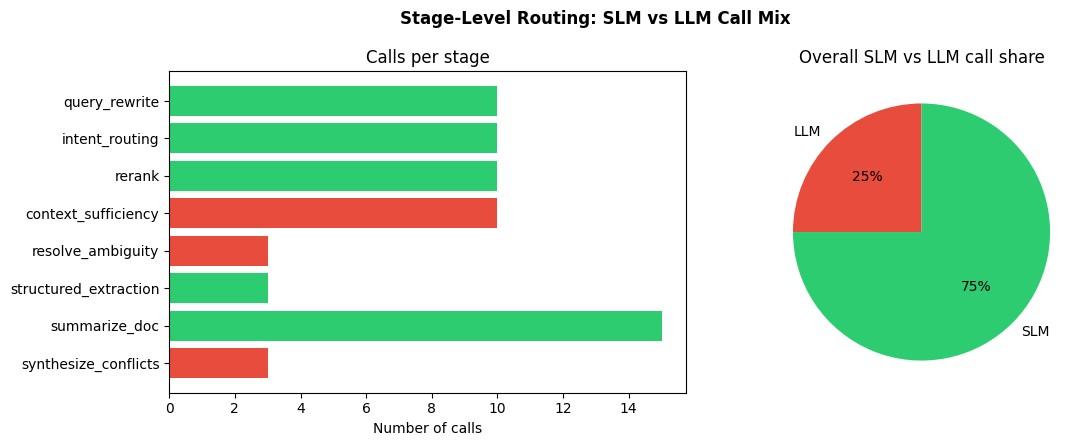

In [49]:
# ============================================================
# CALL-MIX / COST COMPARISON: HYBRID PIPELINE vs. LLM-ONLY (GPT-4o + RAG)
# ============================================================

# Stratified sample: every 6th question -> 10 questions spanning categories/difficulties,
# small enough to keep this cheap even with LLM calls in the mix.
HYBRID_SAMPLE_INDICES = list(range(0, len(MEDILEARN_QUESTIONS), 6))
hybrid_sample_questions = [MEDILEARN_QUESTIONS[i]["question"] for i in HYBRID_SAMPLE_INDICES]

_hybrid_call_log.clear()  # reset the log so this run's tally isn't polluted by the 13.2-13.9 smoke tests
hybrid_results = []
for q in hybrid_sample_questions:
    hybrid_results.append(hybrid_rag_generate(q))

call_log_df = pd.DataFrame(_hybrid_call_log)
call_mix = call_log_df.groupby("tier").agg(
    calls=("stage", "count"),
    total_latency_sec=("latency_sec", "sum"),
    mean_latency_sec=("latency_sec", "mean"),
).round(3)

print("=" * 70)
print(f"CALL MIX OVER {len(hybrid_sample_questions)} SAMPLE QUERIES")
print("=" * 70)
display(call_mix)

pct_slm = round(100 * call_mix.loc["SLM", "calls"] / call_mix["calls"].sum(), 1) if "SLM" in call_mix.index else 0.0
pct_llm = round(100 - pct_slm, 1)
print(f"\n{pct_slm}% of pipeline calls stayed on the free local SLM; only {pct_llm}% reached the paid LLM.")

# Cost: only LLM-tier calls (synthesis, ambiguity check, sufficiency check) incur API cost.
# Reuse the same $/token constants as Section 12, Metric 2.
if "PRICE_PER_1M_INPUT" not in dir() or "PRICE_PER_1M_OUTPUT" not in dir():
    print("⚠ PRICE_PER_1M_INPUT / PRICE_PER_1M_OUTPUT not found -- run Section 12, Metric 2 "
          "for real pricing. Using GPT-4.1 defaults ($2.00 / $8.00 per 1M tokens) for now.\n")
    PRICE_PER_1M_INPUT = 2.00
    PRICE_PER_1M_OUTPUT = 8.00
if "avg_cost_gpt4o" not in dir():
    print("⚠ avg_cost_gpt4o not found -- run Section 12, Metric 2 for the LLM-only baseline "
          "cost. Leaving that comparison row blank for now.\n")
    avg_cost_gpt4o = None

llm_stage_calls = call_log_df[call_log_df["tier"] == "LLM"]
approx_llm_tokens_per_call = 220  # rough blended estimate of input+output tokens for these short stage prompts
hybrid_est_cost = len(llm_stage_calls) * (approx_llm_tokens_per_call / 1e6) * \
                  ((PRICE_PER_1M_INPUT + PRICE_PER_1M_OUTPUT) / 2)
hybrid_cost_per_query = hybrid_est_cost / len(hybrid_sample_questions)

cost_comparison = pd.DataFrame({
    "Approach": ["GPT-4o + RAG (LLM-only, Section 12)", "Hybrid SLM–LLM pipeline (Section 13)"],
    "LLM calls per query": [1, round(len(llm_stage_calls) / len(hybrid_sample_questions), 2)],
    "Est. cost per query (USD)": [
        round(avg_cost_gpt4o, 5) if avg_cost_gpt4o is not None else None,
        round(hybrid_cost_per_query, 5),
    ],
}).set_index("Approach")

print("\n" + "=" * 70)
print("ESTIMATED COST: HYBRID PIPELINE vs. LLM-ONLY BASELINE")
print("=" * 70)
display(cost_comparison)

# Visualize the call mix
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Stage-Level Routing: SLM vs LLM Call Mix", fontsize=12, fontweight="bold")

ax = axes[0]
stage_order = ["query_rewrite", "intent_routing", "rerank", "context_sufficiency",
               "resolve_ambiguity", "structured_extraction", "summarize_doc", "synthesize_conflicts"]
stage_counts = call_log_df["stage"].value_counts().reindex(stage_order).fillna(0)
stage_tiers = [STAGE_MODEL_MAP.get(s, {}).get("model", "?") for s in stage_order]
colors = ["#2ecc71" if t == "SLM" else "#e74c3c" for t in stage_tiers]
ax.barh(stage_order, stage_counts.values, color=colors)
ax.set_xlabel("Number of calls")
ax.set_title("Calls per stage")
ax.invert_yaxis()

ax = axes[1]
ax.pie(call_mix["calls"], labels=call_mix.index, autopct="%1.0f%%",
       colors=["#2ecc71" if i == "SLM" else "#e74c3c" for i in call_mix.index], startangle=90)
ax.set_title("Overall SLM vs LLM call share")

plt.tight_layout()
plt.show()


## 13.13 Save Hybrid Pipeline Results

Same pattern as Section 12's extended metrics: write a new, separate JSON file so nothing from
Sections 10 or 12 is touched or overwritten.

In [50]:
# ============================================================
# SAVE SECTION 13 RESULTS (new file — does not touch Sections 10/12 outputs)
# ============================================================

hybrid_summary = {
    "design_decision_map": STAGE_MODEL_MAP,
    "demo_traces": demo_traces,
    "call_mix": call_mix.to_dict(),
    "cost_comparison": cost_comparison.to_dict(),
    "sample_size": len(hybrid_sample_questions),
}

HYBRID_RESULTS_PATH = os.path.join(DRIVE_RESULTS_DIR, "module3_hybrid_pipeline_metrics.json")
with open(HYBRID_RESULTS_PATH, "w") as f:
    json.dump(hybrid_summary, f, indent=2, default=str)

print(f"✅ Hybrid pipeline results saved → {HYBRID_RESULTS_PATH}")
print("\n" + "=" * 80)
print("SECTION 13 COMPLETE — SLM–LLM hybrid pipeline implemented, 8 stages:")
for stage, info in STAGE_MODEL_MAP.items():
    print(f"  [{info['model']}] {stage}")
print("=" * 80)


✅ Hybrid pipeline results saved → /home/DHS-SLM-Workshop/SLM_Workshop/eval/results/module3_hybrid_pipeline_metrics.json

SECTION 13 COMPLETE — SLM–LLM hybrid pipeline implemented, 8 stages:
  [SLM] query_rewrite
  [SLM] intent_routing
  [SLM] rerank
  [SLM] structured_extraction
  [SLM] summarize_doc
  [LLM] synthesize_conflicts
  [LLM] resolve_ambiguity
  [LLM] context_sufficiency
